# Reporter Assay Benchmarks

This notebook downloads and scores VexSeq and MFASS datasets then compares model predictions against the measured effects.

In [1]:
import os
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pysam
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import gaussian_kde
from sklearn.metrics import precision_recall_curve, average_precision_score
from tqdm import tqdm

# 5kb on each side of splice site = 10,001 bp total window
WINDOW_HALF = 5000
SEQ_LEN = 2 * WINDOW_HALF + 1

# reference genome path used by both datasets
FASTA_PATH = Path("vex_seq/hg19.fa")

In [2]:
# reverse complement
COMP = str.maketrans("ACGTNacgtn", "TGCANtgcan")

def revcomp(seq):
    return seq.translate(COMP)[::-1]

BASE_TO_IDX = {"A": 0, "C": 1, "G": 2, "T": 3}

def one_hot(seq):
    seq = seq.upper()
    arr = np.zeros((len(seq), 4), dtype=np.float32)
    for i, base in enumerate(seq):
        if base in BASE_TO_IDX:
            arr[i, BASE_TO_IDX[base]] = 1.0
    return arr

In [3]:

def get_window(chrom, center, half=WINDOW_HALF):
    """fetch a window of sequence centered on a position, pad with Ns at edges"""
    chrom_len = fasta.get_reference_length(str(chrom))

    start1 = int(center) - half
    end1 = int(center) + half

    left_pad = max(0, 1 - start1)
    right_pad = max(0, end1 - chrom_len)

    fetch_start = max(0, start1 - 1)
    fetch_end = min(chrom_len, end1)

    seq = fasta.fetch(str(chrom), fetch_start, fetch_end).upper()

    if left_pad:
        seq = "N" * left_pad + seq
    if right_pad:
        seq = seq + "N" * right_pad

    return seq, start1, end1


def build_ref_alt_pair(chrom, center, var_pos, ref_allele, alt_allele):
    """build reference and alternate sequences for a variant"""
    ref_seq, start1, end1 = get_window(chrom, center)
    ref_allele = ref_allele.upper()
    alt_allele = alt_allele.upper()

    idx = int(var_pos) - start1
    variant_is_upstream = idx < WINDOW_HALF

    if not (0 <= idx < len(ref_seq) - len(ref_allele) + 1):
        return None, None, "variant outside window"

    genome_ref = ref_seq[idx:idx + len(ref_allele)]
    if genome_ref != ref_allele:
        return None, None, f"ref mismatch: expected {ref_allele}, got {genome_ref}"

    alt_seq = ref_seq[:idx] + alt_allele + ref_seq[idx + len(ref_allele):]

    expected_len = 2 * WINDOW_HALF + 1
    len_diff = len(alt_seq) - expected_len

    if len_diff != 0:
        chrom_len = fasta.get_reference_length(str(chrom))

        if variant_is_upstream:
            if len_diff > 0:
                alt_seq = alt_seq[len_diff:]
            else:
                need = -len_diff
                new_start = start1 - 1 - need
                if new_start < 0:
                    extra = fasta.fetch(str(chrom), 0, start1 - 1).upper()
                    extra = "N" * (need - len(extra)) + extra
                else:
                    extra = fasta.fetch(str(chrom), new_start, start1 - 1).upper()
                alt_seq = extra + alt_seq
        else:
            if len_diff > 0:
                alt_seq = alt_seq[:expected_len]
            else:
                need = -len_diff
                extra_end = min(chrom_len, end1 + need)
                extra = fasta.fetch(str(chrom), end1, extra_end).upper()
                if len(extra) < need:
                    extra = extra + "N" * (need - len(extra))
                alt_seq = alt_seq + extra

    assert len(ref_seq) == expected_len, f"ref_seq wrong length: {len(ref_seq)}"
    assert len(alt_seq) == expected_len, f"alt_seq wrong length: {len(alt_seq)}"

    return ref_seq, alt_seq, None

# VexSeq

Data from the MMSplice paper, originally a CAGI challenge. Reference genome: hg19.

Three files from the [MMSplice GitHub](https://github.com/gagneurlab/MMSplice_paper/tree/master/data/vexseq):
- **train.csv** — training set with delta-PSI labels
- **test.csv** — test set 
- **truth.tsv** — held-out test labels

In [4]:
vex_data_dir = Path("vex_seq/data")
vex_data_dir.mkdir(exist_ok=True)

URLS = {
    "train": "https://raw.githubusercontent.com/gagneurlab/MMSplice_paper/master/data/vexseq/HepG2_delta_PSI_CAGI_training.csv",
    "test": "https://raw.githubusercontent.com/gagneurlab/MMSplice_paper/master/data/vexseq/HepG2_delta_PSI_CAGI_testing.csv",
    "truth": "https://raw.githubusercontent.com/gagneurlab/MMSplice_paper/master/data/vexseq/Vexseq_HepG2_delta_PSI_CAGI_test_true.tsv",
}

for name, url in URLS.items():
    ext = "csv" if url.endswith(".csv") else "tsv"
    path = vex_data_dir / f"{name}.{ext}"
    if not path.exists():
        print(f"downloading {name}...")
        os.system(f'curl -sL "{url}" -o "{path}"')


In [5]:
train = pd.read_csv(vex_data_dir / "train.csv")
test = pd.read_csv(vex_data_dir / "test.csv")
truth = pd.read_csv(vex_data_dir / "truth.tsv", sep="\t")

print(f"train: {len(train):,} variants")
print(f"test:  {len(test):,} variants")
print(f"truth: {len(truth):,} labels")

train: 957 variants
test:  1,098 variants
truth: 1,098 labels


In [6]:
train.head()

,ID,seqnames,start,end,width,strand,hg19_variant_position,reference,variant,HepG2_delta_psi,HepG2_ref_psi,CADD_PHRED,CADD_RAW,PhastCons,PhyloP
0,chr1_114161116_C_A,chr1,114161154,114161228,75,+,114161116,C,A,11.578092,48.884934,-8.376734,-1.642017,-0.471327,-1.415867
1,chr1_114161130_T_C,chr1,114161154,114161228,75,+,114161130,T,C,-4.362399,48.884934,-11.691734,-2.061542,-0.453327,-0.881867
2,chr1_114161136_AT_A,chr1,114161154,114161228,75,+,114161136,AT,A,2.054074,48.884934,0.000000,0.000000,-0.471327,-3.730867
3,chr1_114161147_C_T,chr1,114161154,114161228,75,+,114161147,C,T,-18.454982,48.884934,-10.807734,-1.897793,-0.471327,-2.361867
4,chr1_114161148_G_A,chr1,114161154,114161228,75,+,114161148,G,A,-21.979417,48.884934,-11.478734,-2.011739,-0.471327,-2.385867


In [7]:
test.head()

,seqnames,start,end,width,strand,ID,hg19_variant_position,reference,variant,HepG2_ref_psi
0,chr10,114724315,114724383,69,+,chr10_114724268_T_C,114724268,T,C,89.024627
1,chr10,114724315,114724383,69,+,chr10_114724279_A_G,114724279,A,G,89.024627
2,chr10,114724315,114724383,69,+,chr10_114724280_T_G,114724280,T,G,89.024627
3,chr10,114724315,114724383,69,+,chr10_114724285_A_C,114724285,A,C,89.024627
4,chr10,114724315,114724383,69,+,chr10_114724289_C_A,114724289,C,A,89.024627


In [8]:
truth.head()

,ID,chromosome,hg19_variant_position,reference,variant,exon_start,exon_end,HepG2_delta_psi
0,chr10_114724268_T_C,chr10,114724268,T,C,114724315,114724383,-3.362128
1,chr10_114724279_A_G,chr10,114724279,A,G,114724315,114724383,-2.645510
2,chr10_114724280_T_G,chr10,114724280,T,G,114724315,114724383,-4.144964
3,chr10_114724285_A_C,chr10,114724285,A,C,114724315,114724383,-4.767620
4,chr10_114724289_C_A,chr10,114724289,C,A,114724315,114724383,-2.762261


In [9]:
# width should equal end - start + 1
computed_width = train["end"] - train["start"] + 1
assert (computed_width == train["width"]).all()

In [10]:
print(f"delta-PSI range: {train['HepG2_delta_psi'].min():.1f} to {train['HepG2_delta_psi'].max():.1f}")
print(f"delta-PSI mean: {train['HepG2_delta_psi'].mean():.2f}")
print(f"delta-PSI std: {train['HepG2_delta_psi'].std():.2f}")

delta-PSI range: -88.7 to 53.9
delta-PSI mean: -2.12
delta-PSI std: 14.34


The test CSV doesn't include delta-PSI values merge from truth file.

In [11]:
train["chrom"] = train["seqnames"].astype(str)
train["pos"] = train["hg19_variant_position"].astype(int)
train["ref"] = train["reference"].astype(str)
train["alt"] = train["variant"].astype(str)

test["chrom"] = test["seqnames"].astype(str)
test["pos"] = test["hg19_variant_position"].astype(int)
test["ref"] = test["reference"].astype(str)
test["alt"] = test["variant"].astype(str)

truth["chrom"] = truth["chromosome"].astype(str)
truth["pos"] = truth["hg19_variant_position"].astype(int)
truth["ref"] = truth["reference"].astype(str)
truth["alt"] = truth["variant"].astype(str)

In [12]:
key_cols = ["chrom", "pos", "ref", "alt"]
truth_labels = truth[key_cols + ["HepG2_delta_psi"]].drop_duplicates(subset=key_cols)

test_merged = test.merge(truth_labels, on=key_cols, how="left")

missing = test_merged["HepG2_delta_psi"].isna().sum()
print(f"test variants missing labels: {missing}")
assert missing == 0, "some test variants couldn't be matched to truth"

test variants missing labels: 0


In [13]:
train["split"] = "train"
test_merged["split"] = "test"

keep_cols = ["seqnames", "start", "end", "strand", "hg19_variant_position",
             "reference", "variant", "HepG2_delta_psi", "split"]

vex_combined = pd.concat([train[keep_cols], test_merged[keep_cols]], ignore_index=True)
print(f"combined dataset: {len(vex_combined):,} variants")
print(f"  train: {(vex_combined['split'] == 'train').sum():,}")
print(f"  test:  {(vex_combined['split'] == 'test').sum():,}")

combined dataset: 2,055 variants
  train: 957
  test:  1,098


In [14]:
n_before = len(vex_combined)
vex_combined = vex_combined.drop_duplicates()
n_removed = n_before - len(vex_combined)
print(f"removed {n_removed} duplicate rows")
print(f"final: {len(vex_combined):,} unique variants")

removed 0 duplicate rows
final: 2,055 unique variants


Majority SNVs with some indels.

In [15]:
ref_lens = vex_combined["reference"].str.len()
alt_lens = vex_combined["variant"].str.len()

is_snv = (ref_lens == 1) & (alt_lens == 1)
is_insertion = ref_lens < alt_lens
is_deletion = ref_lens > alt_lens

print(f"variant types:")
print(f"  SNVs:       {is_snv.sum():,} ({100 * is_snv.mean():.1f}%)")
print(f"  insertions: {is_insertion.sum():,} ({100 * is_insertion.mean():.1f}%)")
print(f"  deletions:  {is_deletion.sum():,} ({100 * is_deletion.mean():.1f}%)")


variant types:
  SNVs:       1,960 (95.4%)
  insertions: 9 (0.4%)
  deletions:  75 (3.6%)


### Distributions

Delta-PSI is in percentage units. 

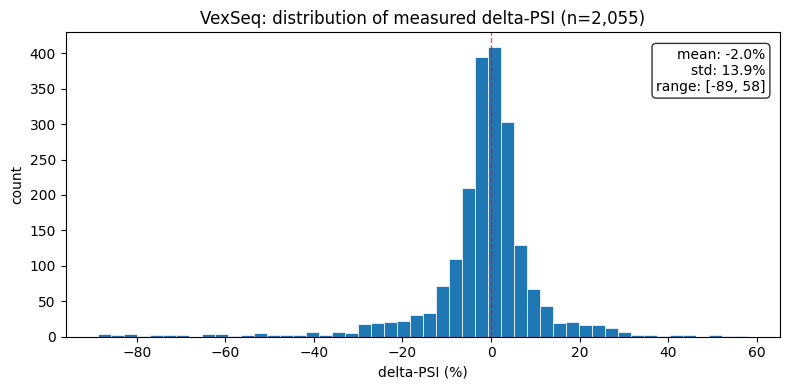

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

delta_psi = vex_combined["HepG2_delta_psi"].values
ax.hist(delta_psi, bins=50, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="red", linestyle="--", linewidth=1, alpha=0.7)

ax.set_xlabel("delta-PSI (%)")
ax.set_ylabel("count")
ax.set_title(f"VexSeq: distribution of measured delta-PSI (n={len(delta_psi):,})")

textstr = f"mean: {delta_psi.mean():.1f}%\nstd: {delta_psi.std():.1f}%\nrange: [{delta_psi.min():.0f}, {delta_psi.max():.0f}]"
ax.text(0.98, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment="top", horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

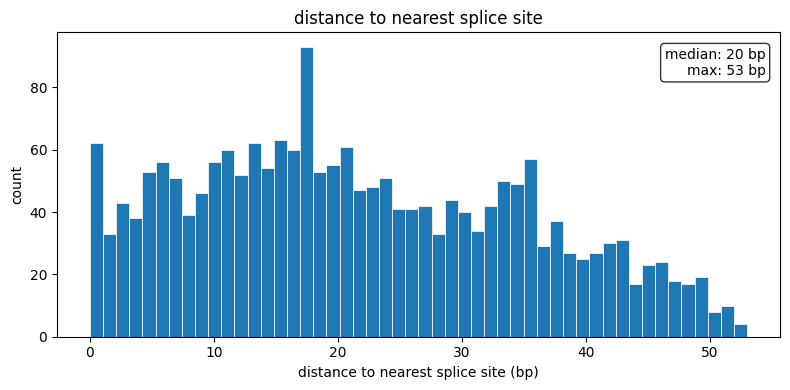

distance summary:
  variants at splice site (0bp): 29
  variants within 10bp: 477
  variants within 50bp: 2,041
  variants > 100bp away: 0


In [17]:
pos = vex_combined["hg19_variant_position"].values
exon_start = vex_combined["start"].values
exon_end = vex_combined["end"].values

dist_to_start = np.abs(pos - exon_start)
dist_to_end = np.abs(pos - exon_end)
dist_to_nearest = np.minimum(dist_to_start, dist_to_end)

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(dist_to_nearest, bins=50, edgecolor="white", linewidth=0.5)
ax.set_xlabel("distance to nearest splice site (bp)")
ax.set_ylabel("count")
ax.set_title("distance to nearest splice site")
ax.text(0.98, 0.95, f"median: {np.median(dist_to_nearest):.0f} bp\nmax: {dist_to_nearest.max():,} bp",
        transform=ax.transAxes, fontsize=10, verticalalignment="top", horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

print(f"distance summary:")
print(f"  variants at splice site (0bp): {(dist_to_nearest == 0).sum():,}")
print(f"  variants within 10bp: {(dist_to_nearest <= 10).sum():,}")
print(f"  variants within 50bp: {(dist_to_nearest <= 50).sum():,}")
print(f"  variants > 100bp away: {(dist_to_nearest > 100).sum():,}")

### Extract sequences

For each variant we extract four 10kb sequences centered on the exon boundaries (start and end, ref and alt alleles). Minus strand sequences are reverse complemented.

In [18]:
assert FASTA_PATH.exists(), f"need hg19 reference genome at {FASTA_PATH}"
fasta = pysam.FastaFile(str(FASTA_PATH))
print(f"loaded {FASTA_PATH}")


loaded vex_seq/hg19.fa


In [19]:
vex_seqs = {
    "exon_start_ref": [],
    "exon_start_alt": [],
    "exon_end_ref": [],
    "exon_end_alt": []
}

vex_meta = {
    "chrom": [],
    "pos": [],
    "ref": [],
    "alt": [],
    "strand": [],
    "exon_start": [],
    "exon_end": [],
    "delta_psi": [],
    "split": []
}

skipped = []

for r in tqdm(vex_combined.itertuples(index=False), total=len(vex_combined), desc="vexseq sequences"):
    chrom = str(r.seqnames)
    strand = str(r.strand)
    pos = int(r.hg19_variant_position)
    ref = str(r.reference)
    alt = str(r.variant)
    ex_start = int(r.start)
    ex_end = int(r.end)

    if strand not in {"+", "-"}:
        skipped.append((pos, f"invalid strand: {strand}"))
        continue

    ref_start, alt_start, err = build_ref_alt_pair(chrom, ex_start, pos, ref, alt)
    if err:
        skipped.append((pos, f"exon_start: {err}"))
        continue

    ref_end, alt_end, err = build_ref_alt_pair(chrom, ex_end, pos, ref, alt)
    if err:
        skipped.append((pos, f"exon_end: {err}"))
        continue

    if strand == "-":
        ref_start, alt_start = revcomp(ref_start), revcomp(alt_start)
        ref_end, alt_end = revcomp(ref_end), revcomp(alt_end)

    vex_seqs["exon_start_ref"].append(ref_start)
    vex_seqs["exon_start_alt"].append(alt_start)
    vex_seqs["exon_end_ref"].append(ref_end)
    vex_seqs["exon_end_alt"].append(alt_end)

    vex_meta["chrom"].append(chrom)
    vex_meta["pos"].append(pos)
    vex_meta["ref"].append(ref)
    vex_meta["alt"].append(alt)
    vex_meta["strand"].append(strand)
    vex_meta["exon_start"].append(ex_start)
    vex_meta["exon_end"].append(ex_end)
    vex_meta["delta_psi"].append(float(r.HepG2_delta_psi))
    vex_meta["split"].append(str(r.split))

fasta.close()

n_vex = len(vex_meta["chrom"])
n_skip = len(skipped)
print(f"built sequences for {n_vex:,} variants ({n_skip:,} skipped)")

if skipped:
    print(f"skipped {len(skipped):,} variants:")
    reasons = {}
    for pos, reason in skipped:
        key = reason.split(":")[0]
        reasons[key] = reasons.get(key, 0) + 1
    for reason, count in sorted(reasons.items(), key=lambda x: -x[1]):
        print(f"  {count:,} - {reason}")
else:
    print("no variants skipped")

vexseq sequences: 100%|██████████| 2055/2055 [00:00<00:00, 11818.75it/s]

built sequences for 2,055 variants (0 skipped)
no variants skipped


In [20]:
print(f"one-hot encoding {n_vex:,} variants x 4 sequences...")

vex_encoded = {}
for key, seq_list in vex_seqs.items():
    arr = np.zeros((n_vex, SEQ_LEN, 4), dtype=np.float32)
    for i, seq in enumerate(seq_list):
        arr[i] = one_hot(seq)
    vex_encoded[key] = arr
    print(f"  {key}: {arr.shape}")

one-hot encoding 2,055 variants x 4 sequences...
  exon_start_ref: (2055, 10001, 4)
  exon_start_alt: (2055, 10001, 4)
  exon_end_ref: (2055, 10001, 4)
  exon_end_alt: (2055, 10001, 4)


In [21]:
vex_out = vex_data_dir / "vex_seq.h5"

with h5py.File(vex_out, "w") as f:
    seq_grp = f.create_group("seqs")
    for key, arr in vex_encoded.items():
        seq_grp.create_dataset(key, data=arr, compression="gzip", compression_opts=4)

    meta_grp = f.create_group("meta")
    meta_grp.create_dataset("chrom", data=np.array(vex_meta["chrom"], dtype="S24"))
    meta_grp.create_dataset("pos", data=np.array(vex_meta["pos"], dtype=np.int64))
    meta_grp.create_dataset("ref", data=np.array(vex_meta["ref"], dtype="S256"))
    meta_grp.create_dataset("alt", data=np.array(vex_meta["alt"], dtype="S256"))
    meta_grp.create_dataset("strand", data=np.array(vex_meta["strand"], dtype="S1"))
    meta_grp.create_dataset("exon_start", data=np.array(vex_meta["exon_start"], dtype=np.int64))
    meta_grp.create_dataset("exon_end", data=np.array(vex_meta["exon_end"], dtype=np.int64))
    meta_grp.create_dataset("delta_psi", data=np.array(vex_meta["delta_psi"], dtype=np.float32))
    meta_grp.create_dataset("split", data=np.array(vex_meta["split"], dtype="S8"))

n_train = sum(1 for s in vex_meta['split'] if s == 'train')
n_test = sum(1 for s in vex_meta['split'] if s == 'test')
seq_shape = next(iter(vex_encoded.values())).shape
n_meta = len([k for k in ["chrom", "pos", "ref", "alt", "strand", "exon_start", "exon_end", "delta_psi", "split"]])

print(f"saved vex_seq.h5)")
print(f"  seqs:  {len(vex_encoded)} arrays of shape {seq_shape}")
print(f"  meta:  {n_meta} fields, {n_vex:,} variants ({n_train:,} train, {n_test:,} test)")

saved vex_seq.h5)
  seqs:  4 arrays of shape (2055, 10001, 4)
  meta:  9 fields, 2,055 variants (957 train, 1,098 test)


# MFASS

Data from [MFASS GitHub](https://github.com/KosuriLab/MFASS). Reference genome: hg19.

Single file needed [here](https://github.com/KosuriLab/MFASS/tree/master/processed_data/snv)

In [22]:
mfass_data_dir = Path("mfass/data")
mfass_data_dir.mkdir(exist_ok=True)

snv_url = "https://raw.githubusercontent.com/KosuriLab/MFASS/master/processed_data/snv/snv_data_clean.txt"
snv_path = mfass_data_dir / "snv_data_clean.txt"
os.system(f'curl -sL "{snv_url}" -o "{snv_path}"')


0

The MFASS data has three categories for each oligo (row). We only use the **mutant** rows.

In [23]:
df = pd.read_csv(snv_path, sep="\t")
print(f"loaded {len(df):,} rows")
print(f"\ncategory breakdown:")
print(df["category"].value_counts())

loaded 32,669 rows

category breakdown:
category
mutant     28972
natural     2339
control     1358
Name: count, dtype: int64


In [24]:
df.head()

,id,ensembl_id,sub_id,chr,start,end,strand,intron1_len,exon_len,intron2_len,...,v2_dpsi_R1,v2_dpsi_R2,nat_v1_index,nat_v2_index,nat_seq,v1_dpsi,v2_dpsi,delta_dpsi,strong_lof,strong_lof_v1
0,ENSE00000332835_000,ENSE00000332835,000,chrX,48837777,48837946,-,51,57,62,...,0.000000,0.000000,0.848391,0.830145,GAGGGAGCATGCTTCAGGCAGCCCTTCCGGCATCTACCAGCCATGC...,0.0,0.000000,0.0,False,False
1,ENSE00000332835_007,ENSE00000332835,007,chrX,48837777,48837946,-,51,57,62,...,-0.053480,0.141578,0.848391,0.830145,GAGGGAGCATGCTTCAGGCAGCCCTTCCGGCATCTACCAGCCATGC...,NaN,0.044049,NaN,False,NaN
2,ENSE00000338771_000,ENSE00000338771,000,chr15,41029796,41029965,-,30,99,41,...,0.000000,0.000000,NaN,0.712929,TTTTAAAACCTCTTATACACACCTTGATCTTTTTGTGGCAGGTCTC...,NaN,0.000000,NaN,False,NaN
3,ENSE00000338771_002,ENSE00000338771,002,chr15,41029796,41029965,-,30,99,41,...,-0.599316,-0.806640,NaN,0.712929,TTTTAAAACCTCTTATACACACCTTGATCTTTTTGTGGCAGGTCTC...,NaN,-0.702978,NaN,True,NaN
4,ENSE00000338771_003,ENSE00000338771,003,chr15,41029796,41029965,-,30,99,41,...,0.268491,0.187646,NaN,0.712929,TTTTAAAACCTCTTATACACACCTTGATCTTTTTGTGGCAGGTCTC...,NaN,0.228068,NaN,False,NaN


In [25]:
# natural rows have no variant — confirm they're empty
natural = df[df["category"] == "natural"]
assert natural["ref_allele"].isna().all()
print(f"natural rows: {len(natural):,} (no variants, skipping these)")

natural rows: 2,339 (no variants, skipping these)


Keep only mutant rows and rename columns to match the VexSeq.

In [26]:
df_mut = df[df["category"] == "mutant"].copy()

df_mut = df_mut.rename(columns={
    "chr": "chrom",
    "ref_allele": "ref",
    "alt_allele": "alt",
    "snp_position": "pos",
})
df_mut["pos"] = df_mut["pos"].astype(int)

print(f"mutant rows: {len(df_mut):,}")

mutant rows: 28,972


MFASS only contains SNVs

In [27]:
ref_lens = df_mut["ref"].str.len()
alt_lens = df_mut["alt"].str.len()

is_snv = (ref_lens == 1) & (alt_lens == 1)
is_insertion = ref_lens < alt_lens
is_deletion = ref_lens > alt_lens

print(f"snvs: {is_snv.sum():,} ({100 * is_snv.mean():.1f}%)")
print(f"insertions: {is_insertion.sum():,} ({100 * is_insertion.mean():.1f}%)")
print(f"deletions: {is_deletion.sum():,} ({100 * is_deletion.mean():.1f}%)")

snvs: 28,972 (100.0%)
insertions: 0 (0.0%)
deletions: 0 (0.0%)


### Compute exon boundaries

The listed start/end columns give the genomic coordinates of the full construct (intron1 + exon + intron2). Compute the actual exon boundaries from these genomic coordinates and intron1_len, exon_len, intron2_len columns.

In [28]:
computed_span = df_mut["end"] - df_mut["start"]
expected_span = df_mut["intron1_len"] + df_mut["exon_len"] + df_mut["intron2_len"] - 1

mismatch = (computed_span != expected_span).sum()
if mismatch > 0:
    print(f"rows with inconsistent coordinates: {mismatch}")

In [29]:
df_mut["exon_start"] = df_mut["start"] + df_mut["intron1_len"]
df_mut["exon_end"] = df_mut["exon_start"] + df_mut["exon_len"] - 1

exon_end_check = df_mut["end"] - df_mut["intron2_len"]
end_mismatch = (df_mut["exon_end"] != exon_end_check).sum()
if end_mismatch > 0:
    print(f"exon_end verification: {end_mismatch} mismatches")
print(f"exon sizes: min={df_mut['exon_len'].min()}, median={df_mut['exon_len'].median():.0f}, max={df_mut['exon_len'].max()}")

exon sizes: min=18, median=81, max=99


### Validate oligo strand

MFASS constructs contain a natural (unmodified) sequence for each oligo. Align this against
the hg19 reference genome to determine each construct's orientation:
- **forward** — natural_seq matches the genome directly -> oligo is on the + strand
- **revcomp** — natural_seq matches the reverse complement -> oligo is on the - strand
- **mismatch** — neither match → error, these variants are removed

Then check this derived strand to the annotated `strand` column.


In [30]:
fasta = pysam.FastaFile(str(FASTA_PATH))
print(f"reference genome: {FASTA_PATH.name}")

reference genome: hg19.fa


In [31]:
# check if natural_seq matches genome forward or revcomp
orientations = []

for r in tqdm(df_mut.itertuples(index=False), total=len(df_mut), desc="checking"):
    genome_seq = fasta.fetch(str(r.chrom), int(r.start) - 1, int(r.end)).upper()
    natural_seq = str(r.natural_seq).upper()

    if genome_seq == natural_seq:
        orientations.append("forward")
    elif genome_seq == revcomp(natural_seq):
        orientations.append("revcomp")
    else:
        orientations.append("mismatch")

df_mut["orientation"] = orientations

n_fwd = (df_mut["orientation"] == "forward").sum()
n_rev = (df_mut["orientation"] == "revcomp").sum()
n_mis = (df_mut["orientation"] == "mismatch").sum()
print(f"\nstrand validation against hg19 reference:")
print(f"  forward (+ strand): {n_fwd:,}")
print(f"  revcomp (- strand): {n_rev:,}")
print(f"  mismatch (removed): {n_mis:,}")

# cross-check: does annotated strand agree with empirical orientation?
strand_disagree = (
    ((df_mut["strand"] == "+") & (df_mut["orientation"] == "revcomp")) |
    ((df_mut["strand"] == "-") & (df_mut["orientation"] == "forward"))
)
n_disagree = strand_disagree.sum()
if n_disagree > 0:
    print(f"\n  strand/orientation disagreements: {n_disagree:,}")
    print(f"  these will be corrected using empirical orientation")
else:
    print(f"\n  all annotated strands match derived orientation")

checking: 100%|██████████| 28972/28972 [00:00<00:00, 102893.19it/s]


strand validation against hg19 reference:
  forward (+ strand): 14,458
  revcomp (- strand): 14,514
  mismatch (removed): 0

  all annotated strands match derived orientation


In [32]:
# remove sequence mismatches
n_mismatch = (df_mut["orientation"] == "mismatch").sum()
if n_mismatch > 0:
    print(f"removing {n_mismatch} rows with sequence mismatches")
    df_mut = df_mut[df_mut["orientation"] != "mismatch"].reset_index(drop=True)
else:
    print(f"all {len(df_mut):,} sequences match the genome")

# correct strand from empirical orientation
df_mut["strand"] = df_mut["orientation"].map({"forward": "+", "revcomp": "-"})

# remove variants without measured delta-psi
unlabeled = df_mut["v2_dpsi"].isna()
n_unlabeled = unlabeled.sum()
if n_unlabeled > 0:
    print(f"\n{n_unlabeled:,} variants have no measured v2_dpsi:")
    print(df_mut.loc[unlabeled, ["ensembl_id", "chrom", "pos", "v1_dpsi", "v2_dpsi"]].head(10))
    df_mut = df_mut[~unlabeled].reset_index(drop=True)
    print(f"removed, {len(df_mut):,} variants remaining")

# count splice-disrupting variants (SDV = |delta-psi| >= 0.5)
n_sdv = (df_mut["v2_dpsi"].abs() >= 0.5).sum()
n_neg = len(df_mut) - n_sdv
print(f"\nlabeled: {len(df_mut):,} ({n_sdv:,} splice-disrupting, {n_neg:,} neutral)")

all 28,972 sequences match the genome

1,239 variants have no measured v2_dpsi:
          ensembl_id  chrom        pos   v1_dpsi  v2_dpsi
35   ENSE00000377990  chr19   45769441 -0.128283      NaN
92   ENSE00000406871  chr17   26912328  0.004460      NaN
155  ENSE00000430832  chr17    3486669       NaN      NaN
156  ENSE00000430832  chr17    3486680       NaN      NaN
210  ENSE00000535552  chr17    3635645 -0.018124      NaN
212  ENSE00000535552  chr17    3635654 -0.018124      NaN
221  ENSE00000535552  chr17    3635722 -0.018124      NaN
259  ENSE00000564470  chr12  120594719 -0.041235      NaN
261  ENSE00000564470  chr12  120594723 -0.039692      NaN
264  ENSE00000564470  chr12  120594740 -0.039692      NaN
removed, 27,733 variants remaining

labeled: 27,733 (1,050 splice-disrupting, 26,683 neutral)


### Distributions


In [33]:
delta_psi = df_mut["v2_dpsi"].values
n_labeled = np.sum(~np.isnan(delta_psi))
print(f"{n_labeled:,} of {len(delta_psi):,} variants have measured delta-psi")

27,733 of 27,733 variants have measured delta-psi


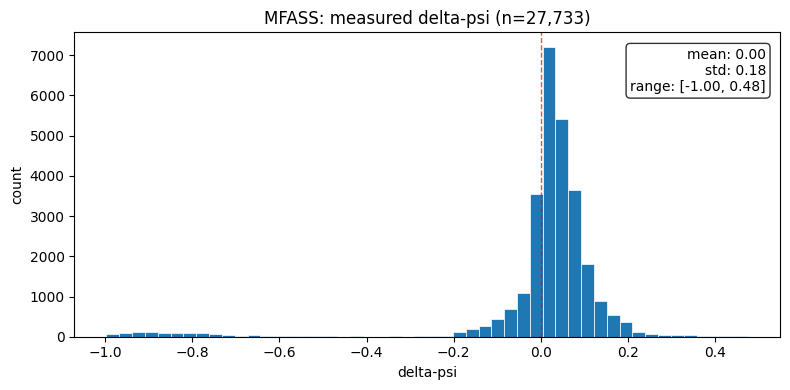

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))

labeled_dpsi = delta_psi[~np.isnan(delta_psi)]
ax.hist(labeled_dpsi, bins=50, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="red", linestyle="--", linewidth=1, alpha=0.7)

ax.set_xlabel("delta-psi")
ax.set_ylabel("count")
ax.set_title(f"MFASS: measured delta-psi (n={len(labeled_dpsi):,})")

stats_text = f"mean: {labeled_dpsi.mean():.2f}\nstd: {labeled_dpsi.std():.2f}\nrange: [{labeled_dpsi.min():.2f}, {labeled_dpsi.max():.2f}]"
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        va="top", ha="right", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

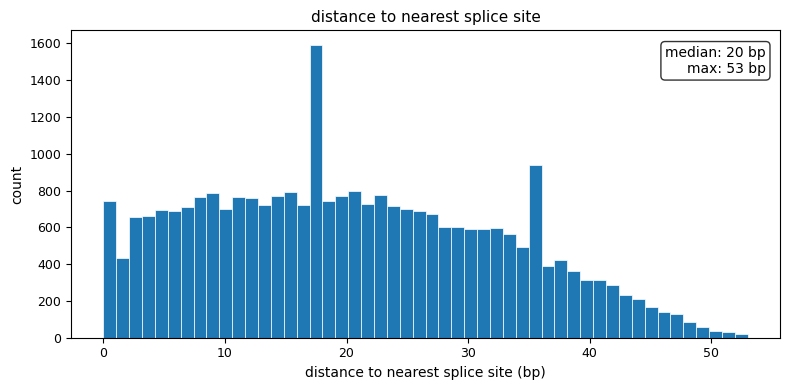

distance summary:
  at splice site (0bp): 332
  within 10bp: 6,839
  within 50bp: 27,681
  > 100bp away: 0


In [48]:
pos = df_mut["pos"].values
exon_start = df_mut["exon_start"].values
exon_end = df_mut["exon_end"].values

dist_to_start = np.abs(pos - exon_start)
dist_to_end = np.abs(pos - exon_end)
dist_to_nearest = np.minimum(dist_to_start, dist_to_end)

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(dist_to_nearest, bins=50, edgecolor="white", linewidth=0.5)
ax.set_xlabel("distance to nearest splice site (bp)")
ax.set_ylabel("count")
ax.set_title("distance to nearest splice site")
ax.text(0.98, 0.95, f"median: {np.median(dist_to_nearest):.0f} bp\nmax: {dist_to_nearest.max():,} bp",
        transform=ax.transAxes, fontsize=10, verticalalignment="top", horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

print(f"distance summary:")
print(f"  at splice site (0bp): {(dist_to_nearest == 0).sum():,}")
print(f"  within 10bp: {(dist_to_nearest <= 10).sum():,}")
print(f"  within 50bp: {(dist_to_nearest <= 50).sum():,}")
print(f"  > 100bp away: {(dist_to_nearest > 100).sum():,}")

### Extract sequences 

Same approach as VexSeq: four 10kb sequences per variant, centered on exon boundaries.

In [36]:
mfass_seqs = {
    "exon_start_ref": [],
    "exon_start_alt": [],
    "exon_end_ref": [],
    "exon_end_alt": []
}

mfass_meta = {
    "chrom": [],
    "pos": [],
    "ref": [],
    "alt": [],
    "strand": [],
    "exon_start": [],
    "exon_end": [],
    "delta_psi": [],
    "exon_id": []
}

skipped = []

for r in tqdm(df_mut.itertuples(index=False), total=len(df_mut), desc="mfass sequences"):
    chrom = str(r.chrom)
    strand = str(r.strand)
    pos = int(r.pos)
    ref = str(r.ref)
    alt = str(r.alt)
    ex_start = int(r.exon_start)
    ex_end = int(r.exon_end)

    if strand not in {"+", "-"}:
        skipped.append((pos, f"invalid strand: {strand}"))
        continue

    ref_start, alt_start, err = build_ref_alt_pair(chrom, ex_start, pos, ref, alt)
    if err:
        skipped.append((pos, f"exon_start: {err}"))
        continue

    ref_end, alt_end, err = build_ref_alt_pair(chrom, ex_end, pos, ref, alt)
    if err:
        skipped.append((pos, f"exon_end: {err}"))
        continue

    if strand == "-":
        ref_start = revcomp(ref_start)
        alt_start = revcomp(alt_start)
        ref_end = revcomp(ref_end)
        alt_end = revcomp(alt_end)

    mfass_seqs["exon_start_ref"].append(ref_start)
    mfass_seqs["exon_start_alt"].append(alt_start)
    mfass_seqs["exon_end_ref"].append(ref_end)
    mfass_seqs["exon_end_alt"].append(alt_end)

    mfass_meta["chrom"].append(chrom)
    mfass_meta["pos"].append(pos)
    mfass_meta["ref"].append(ref)
    mfass_meta["alt"].append(alt)
    mfass_meta["strand"].append(strand)
    mfass_meta["exon_start"].append(ex_start)
    mfass_meta["exon_end"].append(ex_end)

    dpsi = r.v2_dpsi if hasattr(r, "v2_dpsi") and pd.notna(r.v2_dpsi) else np.nan
    mfass_meta["delta_psi"].append(float(dpsi))
    mfass_meta["exon_id"].append(str(r.ensembl_id) if hasattr(r, "ensembl_id") else "")

fasta.close()

n_mfass = len(mfass_meta["chrom"])
print(f"\nbuilt sequences for {n_mfass:,} variants")
print(f"skipped: {len(skipped):,}")

mfass sequences: 100%|██████████| 27733/27733 [00:02<00:00, 9754.20it/s]


built sequences for 27,733 variants
skipped: 0


In [37]:
if skipped:
    reasons = {}
    for pos, reason in skipped:
        key = reason.split(":")[0]
        reasons[key] = reasons.get(key, 0) + 1
    print("skip reasons:")
    for reason, count in sorted(reasons.items(), key=lambda x: -x[1]):
        print(f"  {count:,}: {reason}")

In [38]:
print(f"one-hot encoding {n_mfass:,} variants...")

mfass_encoded = {}
for key, seq_list in mfass_seqs.items():
    arr = np.zeros((n_mfass, SEQ_LEN, 4), dtype=np.float32)
    for i, seq in enumerate(seq_list):
        arr[i] = one_hot(seq)
    mfass_encoded[key] = arr
    print(f"  {key}: {arr.shape}")

one-hot encoding 27,733 variants...
  exon_start_ref: (27733, 10001, 4)
  exon_start_alt: (27733, 10001, 4)
  exon_end_ref: (27733, 10001, 4)
  exon_end_alt: (27733, 10001, 4)


In [39]:
mfass_out = mfass_data_dir / "mfass.h5"

with h5py.File(mfass_out, "w") as f:
    seq_grp = f.create_group("seqs")
    for key, arr in mfass_encoded.items():
        seq_grp.create_dataset(key, data=arr, compression="gzip", compression_opts=4)

    meta_grp = f.create_group("meta")
    meta_grp.create_dataset("chrom", data=np.array(mfass_meta["chrom"], dtype="S24"))
    meta_grp.create_dataset("pos", data=np.array(mfass_meta["pos"], dtype=np.int64))
    meta_grp.create_dataset("ref", data=np.array(mfass_meta["ref"], dtype="S256"))
    meta_grp.create_dataset("alt", data=np.array(mfass_meta["alt"], dtype="S256"))
    meta_grp.create_dataset("strand", data=np.array(mfass_meta["strand"], dtype="S1"))
    meta_grp.create_dataset("exon_start", data=np.array(mfass_meta["exon_start"], dtype=np.int64))
    meta_grp.create_dataset("exon_end", data=np.array(mfass_meta["exon_end"], dtype=np.int64))
    meta_grp.create_dataset("delta_psi", data=np.array(mfass_meta["delta_psi"], dtype=np.float32))
    meta_grp.create_dataset("exon_id", data=np.array(mfass_meta["exon_id"], dtype="S64"))

seq_shape = next(iter(mfass_encoded.values())).shape
n_meta = len([k for k in ["chrom", "pos", "ref", "alt", "strand", "exon_start", "exon_end", "delta_psi", "exon_id"]])

print(f"saved mfass.h5")
print(f"  seqs:  {len(mfass_encoded)} arrays of shape {seq_shape}")
print(f"  meta:  {n_meta} fields, {n_mfass:,} variants")

saved mfass.h5
  seqs:  4 arrays of shape (27733, 10001, 4)
  meta:  9 fields, 27,733 variants


# Model Comparison

Both datasets scored with five models (SpliceAI, Pangolin, SpliceTransformer, and DCNN-ref/-var) compare predictions against the measured ∆PSI values.

Each model produces scores at both exon boundaries for ref and alt alleles. We compute delta scores (alt - ref) and average over acepptor and donor scores of the given exon/variant, then calculate Pearson correlation, Spearman correlation, and area under the precision-recall curve (AUPRC). For MFASS variants with |∆PSI| > 0.5 are postive class and for VexSeq |∆PSI| > 0.1.

In [ ]:
# model colors and style (colorblind-friendly palette)
model_colors = {
    "pangolin":          "#009E73",  # green
    "spliceai":          "#D55E00",  # orange-red
    "splicetransformer": "#E69F00",  # yellow-orange
    "sphaec_ref":        "#56B4E9",  # light blue
    "sphaec_var":        "#0072B2",  # dark blue
    "sphaec_avg":        "#CC79A7",  # pink
    "gencode":           "#666666",  # gray (baseline)
}

def _get_base_model(key):
    """extract base model name from output key"""
    key = key.lower().replace("-", "_").replace(" ", "_")
    if key in model_colors:
        return key
    for base in sorted(model_colors.keys(), key=len, reverse=True):
        if key.startswith(base):
            return base
    return None

def get_color(key):
    """get color for model output"""
    base = _get_base_model(key)
    if base:
        return model_colors[base]
    return "#999999"

ANNOT_SIZE = 12

fig3_main = Path("../../figures/fig3/main")
fig3_sup = Path("../../figures/fig3/sup")
fig3_main.mkdir(parents=True, exist_ok=True)
fig3_sup.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "axes.titleweight": "normal",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
})

out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

models = ["pangolin", "spliceai", "splicetransformer", "sphaec_ref", "sphaec_var"]

model_names = {
    "pangolin": "Pangolin",
    "pangolin_usage": "Pangolin (max usage)",
    "spliceai": "SpliceAI",
    "splicetransformer": "SpliceTransformer",
    "splicetransformer_usage": "SpTransformer (max usage)",
    "sphaec_ref": "DCNN-reference",
    "sphaec_var": "DCNN-variant",
}

datasets = {
    "vexseq": {"path": "vex_seq/data", "prefix": "vex_seq", "thr": 0.10, "psi_scale": 100},
    "mfass": {"path": "mfass/data", "prefix": "mfass", "thr": 0.50, "psi_scale": 1}
}

dataset_names = {"vexseq": "Vex-seq", "mfass": "MFASS"}

In [41]:
def load_scores_as_deltas(path):
    """load h5 and compute deltas (alt - ref) for each head"""
    with h5py.File(path, "r") as f:
        # get meta
        meta = {}
        for k in f["meta"].keys():
            arr = f["meta"][k][:]
            meta[k] = np.array([x.decode() for x in arr]) if arr.dtype.kind == "S" else arr

        # find unique heads and compute deltas
        keys = list(f["scores"].keys())
        heads = set()
        for k in keys:
            for suffix in ["_exon_start_ref", "_exon_start_alt", "_exon_end_ref", "_exon_end_alt"]:
                if k.endswith(suffix):
                    heads.add(k.replace(suffix, ""))

        deltas = {}
        for head in sorted(heads):
            start_ref = f["scores"][f"{head}_exon_start_ref"][:]
            start_alt = f["scores"][f"{head}_exon_start_alt"][:]
            deltas[f"{head}_exon_start_delta"] = start_alt - start_ref

            end_ref = f["scores"][f"{head}_exon_end_ref"][:]
            end_alt = f["scores"][f"{head}_exon_end_alt"][:]
            deltas[f"{head}_exon_end_delta"] = end_alt - end_ref

    return pd.DataFrame(meta), pd.DataFrame(deltas)

# load all data
dfs = {}
for name, cfg in datasets.items():
    meta_df = None
    delta_dfs = {}

    for m in models:
        if m == "pangolin": fname = f"{cfg['prefix']}_pang.h5"
        elif m == "spliceai": fname = f"{cfg['prefix']}_sa.h5"
        elif m == "splicetransformer": fname = f"{cfg['prefix']}_spt.h5"
        else: fname = f"{cfg['prefix']}_{m}.h5"

        path = Path(cfg["path"]) / fname
        if not path.exists():
            continue

        meta, deltas = load_scores_as_deltas(path)
        deltas.columns = [f"{m}_{c}" for c in deltas.columns]
        delta_dfs[m] = deltas

        if meta_df is None:
            meta_df = meta

    # filter mfass to variants with labels
    if name == "mfass":
        mask = meta_df["delta_psi"].notna().values
        meta_df = meta_df[mask].reset_index(drop=True)
        delta_dfs = {m: df[mask].reset_index(drop=True) for m, df in delta_dfs.items()}

    df = meta_df.copy()
    df["y"] = df["delta_psi"].values / cfg["psi_scale"]
    df["label"] = (np.abs(df["y"]) > cfg["thr"]).astype(int)

    for m, delta_df in delta_dfs.items():
        df = pd.concat([df, delta_df], axis=1)

    dfs[name] = df

    n_models = len(delta_dfs)
    delta_cols = [c for c in df.columns if "_delta" in c]
    n_pos = df["label"].sum()
    print(f"{name}: loaded {n_models} models, {len(df):,} variants")
    print(f"  scores: {len(delta_cols)} delta columns, shape ({len(df):,}, {len(delta_cols)})")
    print(f"  labels: {n_pos:,} positives ({100*df['label'].mean():.1f}%), threshold={cfg['thr']:.2f}")

vexseq: loaded 5 models, 2,055 variants
  scores: 74 delta columns, shape (2,055, 74)
  labels: 431 positives (21.0%), threshold=0.10
mfass: loaded 5 models, 27,733 variants
  scores: 74 delta columns, shape (27,733, 74)
  labels: 1,050 positives (3.8%), threshold=0.50


In [42]:
# compute combined delta columns
for name, df in dfs.items():
    is_plus = (df["strand"].values == "+")

    def strand_select(start_col, end_col):
        return np.where(is_plus, df[start_col], df[end_col])

    def avg_boundaries(prefix):
        return (df[f"{prefix}_exon_start_delta"] + df[f"{prefix}_exon_end_delta"]) / 2

    # spliceai: avg of strand-aware acceptor + donor
    acc = strand_select("spliceai_acceptor_exon_start_delta", "spliceai_acceptor_exon_end_delta")
    don = strand_select("spliceai_donor_exon_end_delta", "spliceai_donor_exon_start_delta")
    df["spliceai_cls_delta"] = (acc + don) / 2

    # splicetransformer: cls + tissue usage
    acc = strand_select("splicetransformer_acceptor_exon_start_delta", "splicetransformer_acceptor_exon_end_delta")
    don = strand_select("splicetransformer_donor_exon_end_delta", "splicetransformer_donor_exon_start_delta")
    df["splicetransformer_cls_delta"] = (acc + don) / 2

    usage_cols = []
    for c in df.columns:
        if c.startswith("splicetransformer_usage_") and c.endswith("_exon_start_delta"):
            tissue = c.replace("splicetransformer_usage_", "").replace("_exon_start_delta", "")
            col = f"splicetransformer_usage_{tissue}_delta"
            df[col] = avg_boundaries(f"splicetransformer_usage_{tissue}")
            usage_cols.append(col)
    if usage_cols:
        vals = df[usage_cols].values
        df["splicetransformer_max_usage"] = vals[np.arange(len(df)), np.abs(vals).argmax(axis=1)]

    # pangolin: tissue p_splice + usage
    tissues = [c.replace("pangolin_", "").replace("_p_splice_exon_start_delta", "")
               for c in df.columns if "_p_splice_exon_start_delta" in c]
    p_cols, u_cols = [], []
    for t in tissues:
        df[f"pangolin_{t}_p_splice_delta"] = avg_boundaries(f"pangolin_{t}_p_splice")
        df[f"pangolin_{t}_usage_delta"] = avg_boundaries(f"pangolin_{t}_usage")
        p_cols.append(f"pangolin_{t}_p_splice_delta")
        u_cols.append(f"pangolin_{t}_usage_delta")
    if p_cols:
        vals = df[p_cols].values
        df["pangolin_max_p_splice"] = vals[np.arange(len(df)), np.abs(vals).argmax(axis=1)]
    if u_cols:
        vals = df[u_cols].values
        df["pangolin_max_usage"] = vals[np.arange(len(df)), np.abs(vals).argmax(axis=1)]

    # sphaec: cls + reg_ssu
    for v in ["ref", "var"]:
        p = f"sphaec_{v}"
        acc = strand_select(f"{p}_cls_acceptor_exon_start_delta", f"{p}_cls_acceptor_exon_end_delta")
        don = strand_select(f"{p}_cls_donor_exon_end_delta", f"{p}_cls_donor_exon_start_delta")
        df[f"{p}_cls_delta"] = (acc + don) / 2
        df[f"{p}_reg_ssu_delta"] = avg_boundaries(f"{p}_reg_ssu")

    dfs[name] = df

    n_raw = len([c for c in df.columns if "_delta" in c and "exon_start" in c])
    n_combined = len([c for c in df.columns if c.endswith("_delta") and "exon_" not in c])
    print(f"{name}: {n_combined} combined columns ({n_raw} raw heads → strand-corrected + cross-tissue max)")

vexseq: 29 combined columns (37 raw heads → strand-corrected + cross-tissue max)
mfass: 29 combined columns (37 raw heads → strand-corrected + cross-tissue max)


In [43]:
def get_metrics(y, pred, label):
    mask = np.isfinite(y) & np.isfinite(pred)
    yt, yp, lab = y[mask], pred[mask], label[mask]
    if len(yt) < 3: return np.nan, np.nan, np.nan
    r = stats.pearsonr(yt, yp)[0]
    rho = stats.spearmanr(yt, yp)[0]
    auprc = average_precision_score(lab, np.abs(yp)) if lab.sum() > 0 else np.nan
    return r, rho, auprc

### Combined scatter + bar figures

Density scatter plots of predicted vs measured delta-PSI alongside exonic/intronic metric breakdowns.
Each model uses its classification head (`cls_delta`) or cross-tissue max (`max_p_splice`).

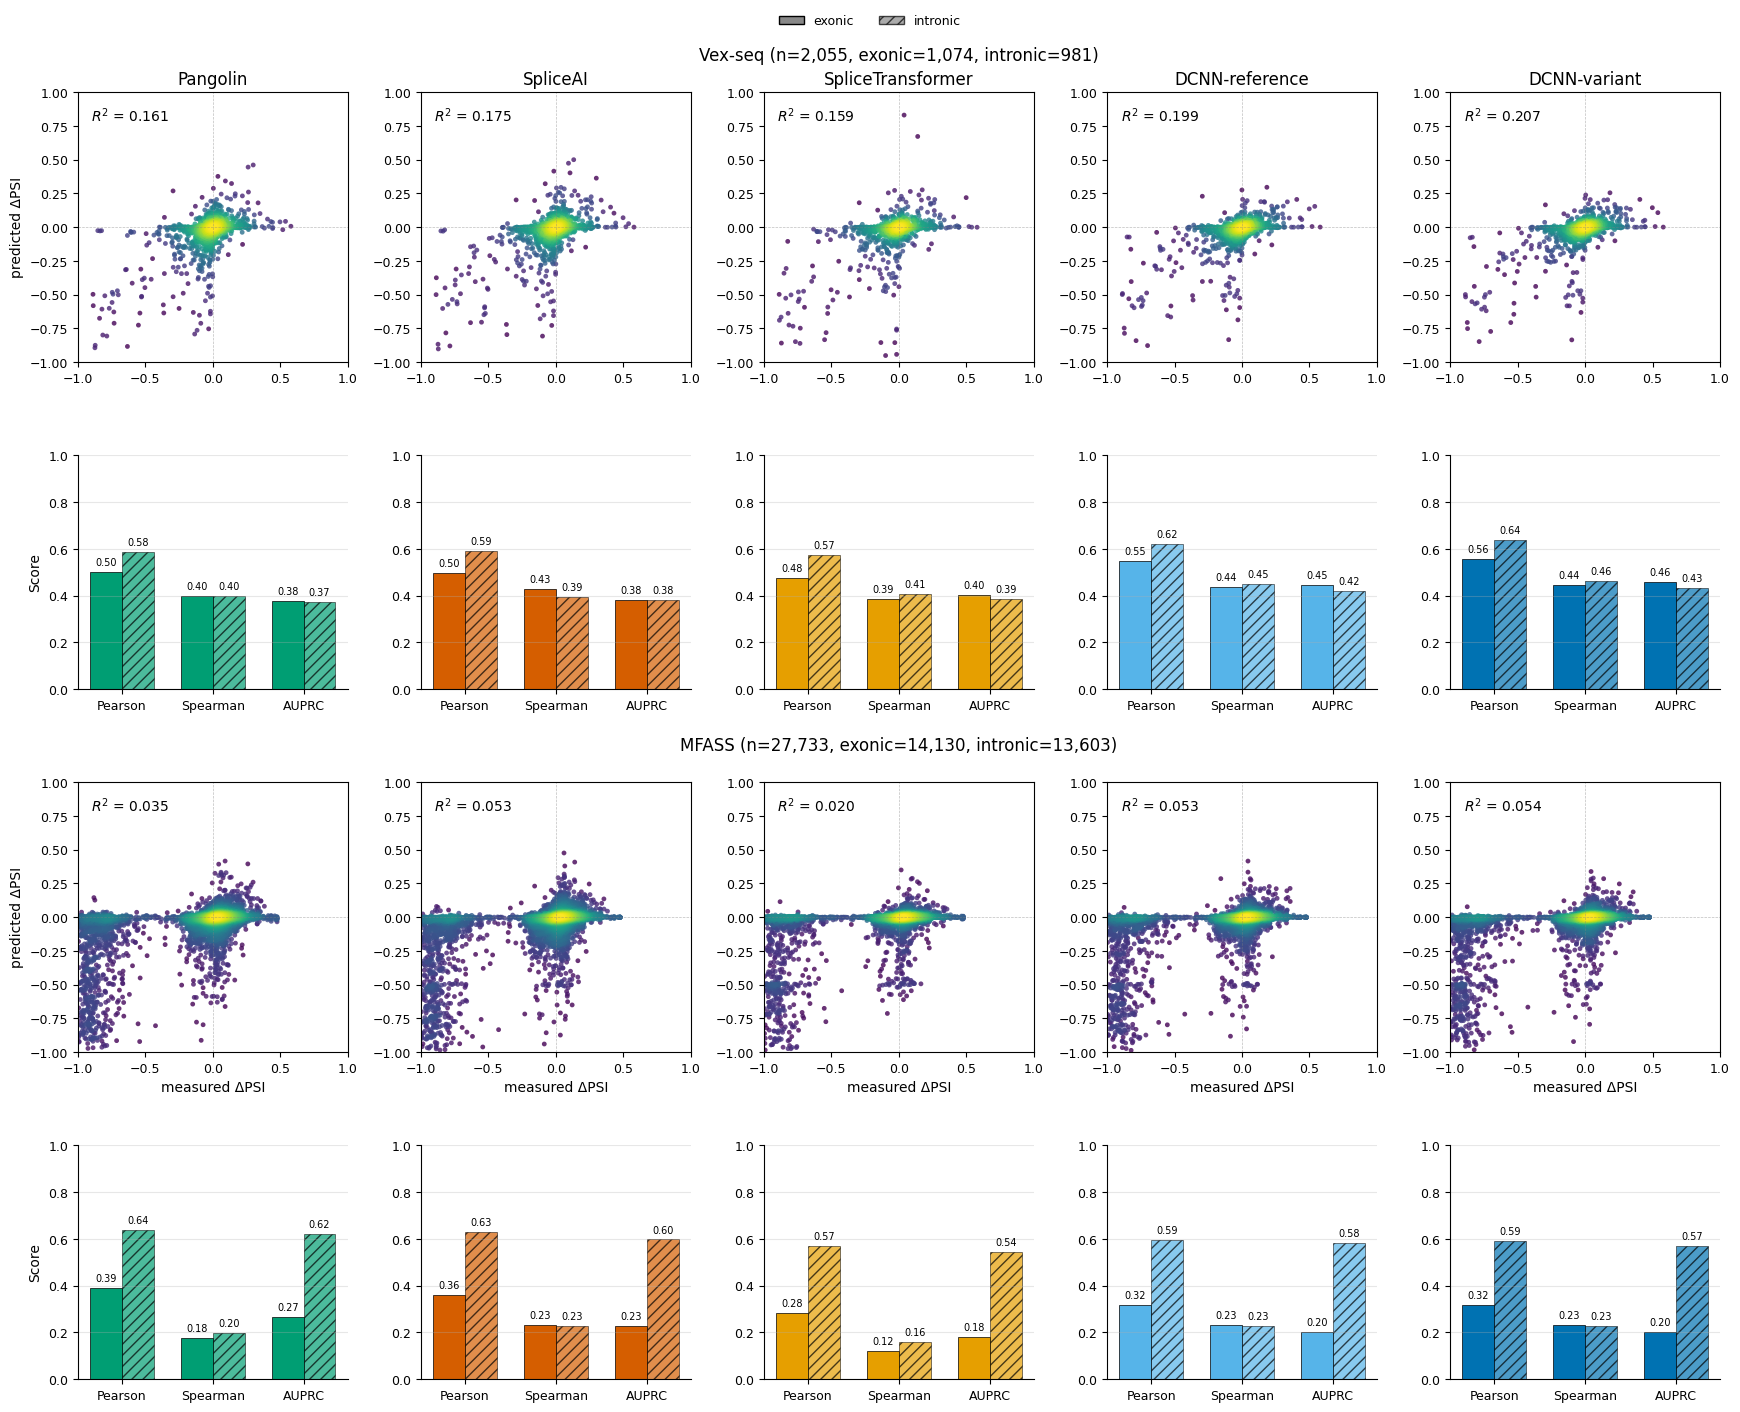

saved output/reporter_assays_combined.png


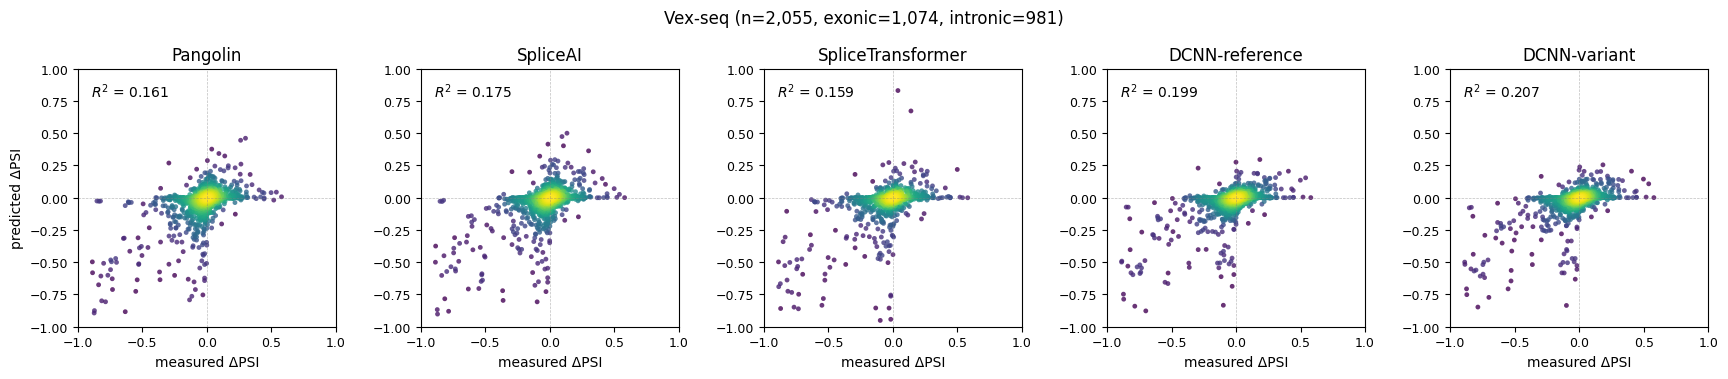

saved output/vexseq_cls_scatter.png


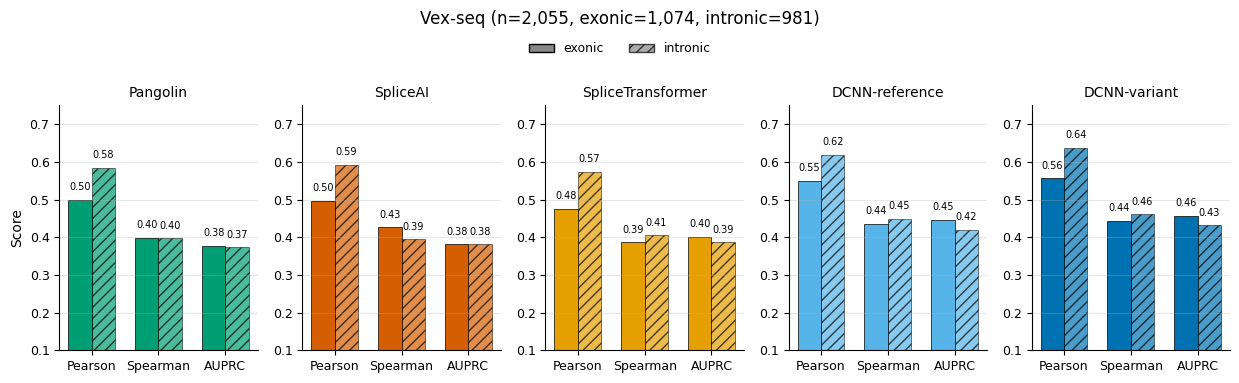

saved output/vexseq_cls_bars.png


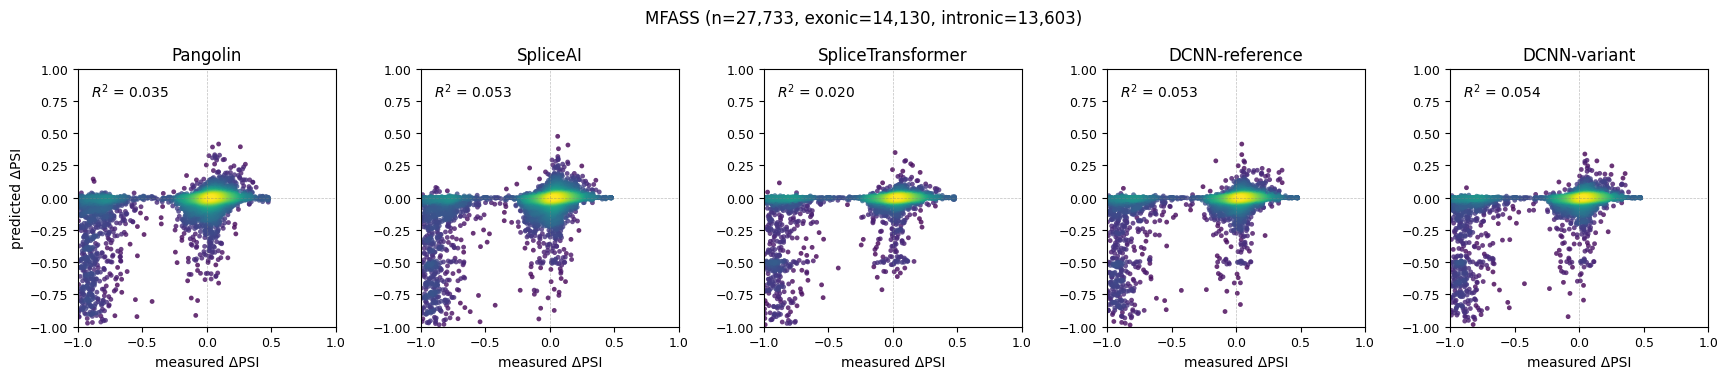

saved output/mfass_cls_scatter.png


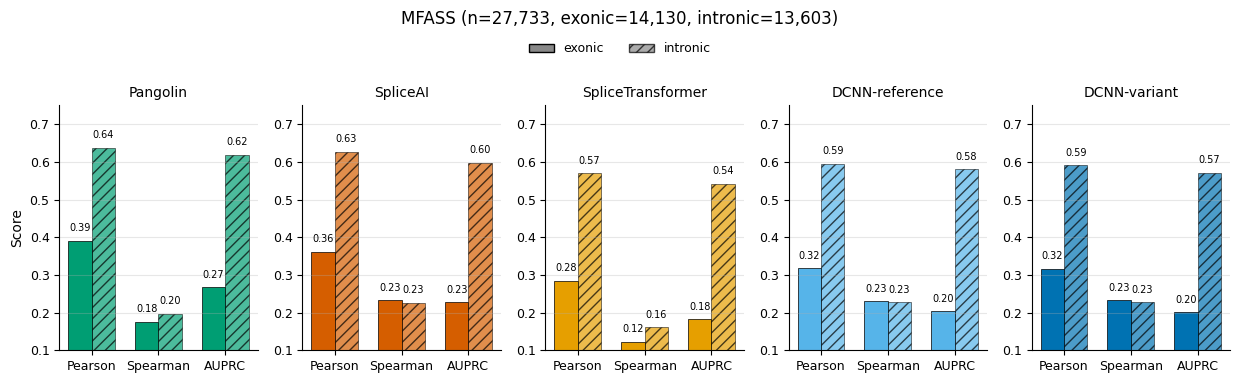

saved output/mfass_cls_bars.png


In [44]:
# combined and separate scatter/bar figures for reporter assays
from scipy.stats import spearmanr

split_cols = {
    "pangolin": "pangolin_max_p_splice",
    "spliceai": "spliceai_cls_delta",
    "splicetransformer": "splicetransformer_cls_delta",
    "sphaec_ref": "sphaec_ref_cls_delta",
    "sphaec_var": "sphaec_var_cls_delta",
}
split_models = ["pangolin", "spliceai", "splicetransformer", "sphaec_ref", "sphaec_var"]


scatter_lims = {"vexseq": 1.0, "mfass": 1.0}

# get available models across all datasets
all_mods = set()
for name, df in dfs.items():
    mods = [m for m in split_models if split_cols[m] in df.columns]
    all_mods.update(mods)
mods = [m for m in split_models if m in all_mods]
nm = len(mods)

# combined figure
n_datasets = len(dfs)
fig, axes = plt.subplots(n_datasets * 2, nm, figsize=(3.5 * nm, 3.5 * n_datasets * 2),
                         gridspec_kw={"height_ratios": [1, 0.6] * n_datasets})

for d_idx, (name, df) in enumerate(dfs.items()):
    cols = split_cols
    y, label = df["y"].values, df["label"].values
    pos = df["pos"].values
    exonic = (pos >= df["exon_start"].values) & (pos <= df["exon_end"].values)
    intronic = ~exonic
    row_scatter = d_idx * 2
    row_bar = d_idx * 2 + 1
    lim = scatter_lims.get(name, max(np.abs(y).max(), max(np.abs(df[cols[m]]).max() for m in mods if cols[m] in df.columns)) * 1.05)

    for j, m in enumerate(mods):
        ax = axes[row_scatter, j]
        if cols[m] not in df.columns:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
            ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
            continue
        x, yp = y, df[cols[m]].values
        mask = np.isfinite(x) & np.isfinite(yp)
        xm, ym = x[mask], yp[mask]
        z = gaussian_kde(np.vstack([xm, ym]))(np.vstack([xm, ym]))
        z_log = np.log1p(z * 1000)
        order = z_log.argsort()
        ax.scatter(xm[order], ym[order], c=z_log[order], cmap="viridis", s=12, alpha=0.8, edgecolors="none")
        r2 = spearmanr(xm, ym)[0] ** 2
        ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}", transform=ax.transAxes, fontsize=10, va="top", ha="left")
        ax.axhline(0, color="gray", ls="--", lw=0.5, alpha=0.5)
        ax.axvline(0, color="gray", ls="--", lw=0.5, alpha=0.5)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
        if j == 0: ax.set_ylabel("predicted \u0394PSI", fontsize=10)
        else: ax.set_ylabel("")
        if d_idx == n_datasets - 1: ax.set_xlabel("measured \u0394PSI", fontsize=10)
        if d_idx == 0: ax.set_title(model_names[m], fontsize=12)

    metrics_c = ["Pearson", "Spearman", "AUPRC"]
    width = 0.35
    for j, m in enumerate(mods):
        ax = axes[row_bar, j]
        if cols[m] not in df.columns:
            ax.set_visible(False); continue
        ex_r, ex_rho, ex_auprc = get_metrics(y[exonic], df[cols[m]].values[exonic], label[exonic])
        in_r, in_rho, in_auprc = get_metrics(y[intronic], df[cols[m]].values[intronic], label[intronic])
        ex_vals = [ex_r, ex_rho, ex_auprc]
        in_vals = [in_r, in_rho, in_auprc]
        x_pos = np.arange(len(metrics_c))
        model_color = get_color(m)
        ax.bar(x_pos - width/2, ex_vals, width, color=model_color, edgecolor="black", linewidth=0.5)
        ax.bar(x_pos + width/2, in_vals, width, color=model_color, edgecolor="black", linewidth=0.5, hatch="///", alpha=0.7)
        for k, (ev, iv) in enumerate(zip(ex_vals, in_vals)):
            if np.isfinite(ev): ax.text(k - width/2, ev + 0.02, f"{ev:.2f}", ha="center", va="bottom", fontsize=7)
            if np.isfinite(iv): ax.text(k + width/2, iv + 0.02, f"{iv:.2f}", ha="center", va="bottom", fontsize=7)
        ax.set_xticks(x_pos); ax.set_xticklabels(metrics_c, fontsize=9)
        ax.set_ylim(0, 1); ax.grid(axis="y", alpha=0.3)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        if j == 0: ax.set_ylabel("Score", fontsize=10)

# legend centered above first bar row
legend_elements = [
    Patch(facecolor="#888888", edgecolor="black", label="exonic"),
    Patch(facecolor="#888888", edgecolor="black", hatch="///", alpha=0.7, label="intronic"),
]
fig.legend(handles=legend_elements, loc="upper center", ncol=2, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, 1.01))

plt.tight_layout()
for d_idx, (name, df) in enumerate(dfs.items()):
    pos = df["pos"].values
    exonic = (pos >= df["exon_start"].values) & (pos <= df["exon_end"].values)
    n_ex, n_in = exonic.sum(), (~exonic).sum()
    ax_left = axes[d_idx * 2, 0]; ax_right = axes[d_idx * 2, -1]
    bbox_l, bbox_r = ax_left.get_position(), ax_right.get_position()
    fig.text((bbox_l.x0 + bbox_r.x1) / 2, bbox_l.y1 + 0.02,
             f"{dataset_names[name]} (n={len(df):,}, exonic={n_ex:,}, intronic={n_in:,})",
             fontsize=12, va="bottom", ha="center")

plt.savefig(f"{out_dir}/reporter_assays_combined.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {out_dir}/reporter_assays_combined.png")

# ===== SEPARATE FIGURES (4 total: scatter + bar per dataset) =====
for name, df in dfs.items():
    cols = split_cols
    y, label = df["y"].values, df["label"].values
    pos = df["pos"].values
    exonic = (pos >= df["exon_start"].values) & (pos <= df["exon_end"].values)
    intronic = ~exonic
    n_ex, n_in = exonic.sum(), intronic.sum()
    ds_mods = [m for m in split_models if cols[m] in df.columns]
    n = len(ds_mods)
    lim = scatter_lims.get(name, max(np.abs(y).max(), max(np.abs(df[cols[m]]).max() for m in ds_mods)) * 1.05)

    # scatter 
    fig, axes_s = plt.subplots(1, n, figsize=(3.5 * n, 3.5), squeeze=False)
    for j, m in enumerate(ds_mods):
        ax = axes_s[0, j]
        x, yp = y, df[cols[m]].values
        mask = np.isfinite(x) & np.isfinite(yp)
        xm, ym = x[mask], yp[mask]
        z = gaussian_kde(np.vstack([xm, ym]))(np.vstack([xm, ym]))
        z_log = np.log1p(z * 1000)
        order = z_log.argsort()
        ax.scatter(xm[order], ym[order], c=z_log[order], cmap="viridis", s=12, alpha=0.8, edgecolors="none")
        r2 = spearmanr(xm, ym)[0] ** 2
        ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}", transform=ax.transAxes, fontsize=10, va="top", ha="left")
        ax.axhline(0, color="gray", ls="--", lw=0.5, alpha=0.5)
        ax.axvline(0, color="gray", ls="--", lw=0.5, alpha=0.5)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
        ax.set_title(model_names[m], fontsize=12)
        if j == 0: ax.set_ylabel("predicted \u0394PSI", fontsize=10)
        ax.set_xlabel("measured \u0394PSI", fontsize=10)
    plt.suptitle(f"{dataset_names[name]} (n={len(df):,}, exonic={n_ex:,}, intronic={n_in:,})",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{out_dir}/{name}_cls_scatter.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"saved {out_dir}/{name}_cls_scatter.png")

    # bars 
    fig, axes_b = plt.subplots(1, n, figsize=(2.5 * n, 3.5), squeeze=False)
    metrics = ["Pearson", "Spearman", "AUPRC"]
    width = 0.35
    for j, m in enumerate(ds_mods):
        ax = axes_b[0, j]
        ex_r, ex_rho, ex_auprc = get_metrics(y[exonic], df[cols[m]].values[exonic], label[exonic])
        in_r, in_rho, in_auprc = get_metrics(y[intronic], df[cols[m]].values[intronic], label[intronic])
        ex_vals = [ex_r, ex_rho, ex_auprc]
        in_vals = [in_r, in_rho, in_auprc]
        x_pos = np.arange(len(metrics))
        model_color = get_color(m)
        ax.bar(x_pos - width/2, ex_vals, width, color=model_color, edgecolor="black", linewidth=0.5)
        ax.bar(x_pos + width/2, in_vals, width, color=model_color, edgecolor="black", linewidth=0.5, hatch="///", alpha=0.7)
        for k, (ev, iv) in enumerate(zip(ex_vals, in_vals)):
            if np.isfinite(ev): ax.text(k - width/2, ev + 0.02, f"{ev:.2f}", ha="center", va="bottom", fontsize=7)
            if np.isfinite(iv): ax.text(k + width/2, iv + 0.02, f"{iv:.2f}", ha="center", va="bottom", fontsize=7)
        ax.set_xticks(x_pos); ax.set_xticklabels(metrics, fontsize=9)
        ax.set_ylim(0.1, 0.75); ax.grid(axis="y", alpha=0.3)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        ax.set_title(model_names[m], fontsize=10)
        if j == 0: ax.set_ylabel("Score", fontsize=10)
    legend_elements = [
        Patch(facecolor="#888888", edgecolor="black", label="exonic"),
        Patch(facecolor="#888888", edgecolor="black", hatch="///", alpha=0.7, label="intronic"),
    ]
    fig.legend(handles=legend_elements, loc="upper center", ncol=2, fontsize=9,
               frameon=False, bbox_to_anchor=(0.5, 1.02))
    plt.suptitle(f"{dataset_names[name]} (n={len(df):,}, exonic={n_ex:,}, intronic={n_in:,})",
                 fontsize=12, y=1.08)
    plt.tight_layout()
    plt.savefig(f"{out_dir}/{name}_cls_bars.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"saved {out_dir}/{name}_cls_bars.png")

### All model outputs

Each model produces multiple outputs (tissue-specific scores, classification heads, etc.). This shows how every output correlates with measured delta-PSI across three metrics.


Vex-seq (n=2055, pos=431, neg=1624)
column                                           pearson   spearman      auprc
--------------------------------------------------------------------------------
sphaec_var_cls_delta                               0.600      0.455      0.443
sphaec_ref_cls_delta                               0.587      0.446      0.432
splicetransformer_usage_Blood_Vessel_delta         0.547      0.336      0.416
splicetransformer_usage_Nerve_delta                0.545      0.327      0.415
splicetransformer_usage_Adipose_Tissue_delta       0.546      0.335      0.415
splicetransformer_usage_Heart_delta                0.550      0.352      0.414
splicetransformer_usage_Skin_delta                 0.547      0.330      0.413
splicetransformer_max_usage                        0.551      0.343      0.413
splicetransformer_usage_Muscle_delta               0.549      0.342      0.411
splicetransformer_usage_Colon_delta                0.543      0.328      0.411
splicetransfo

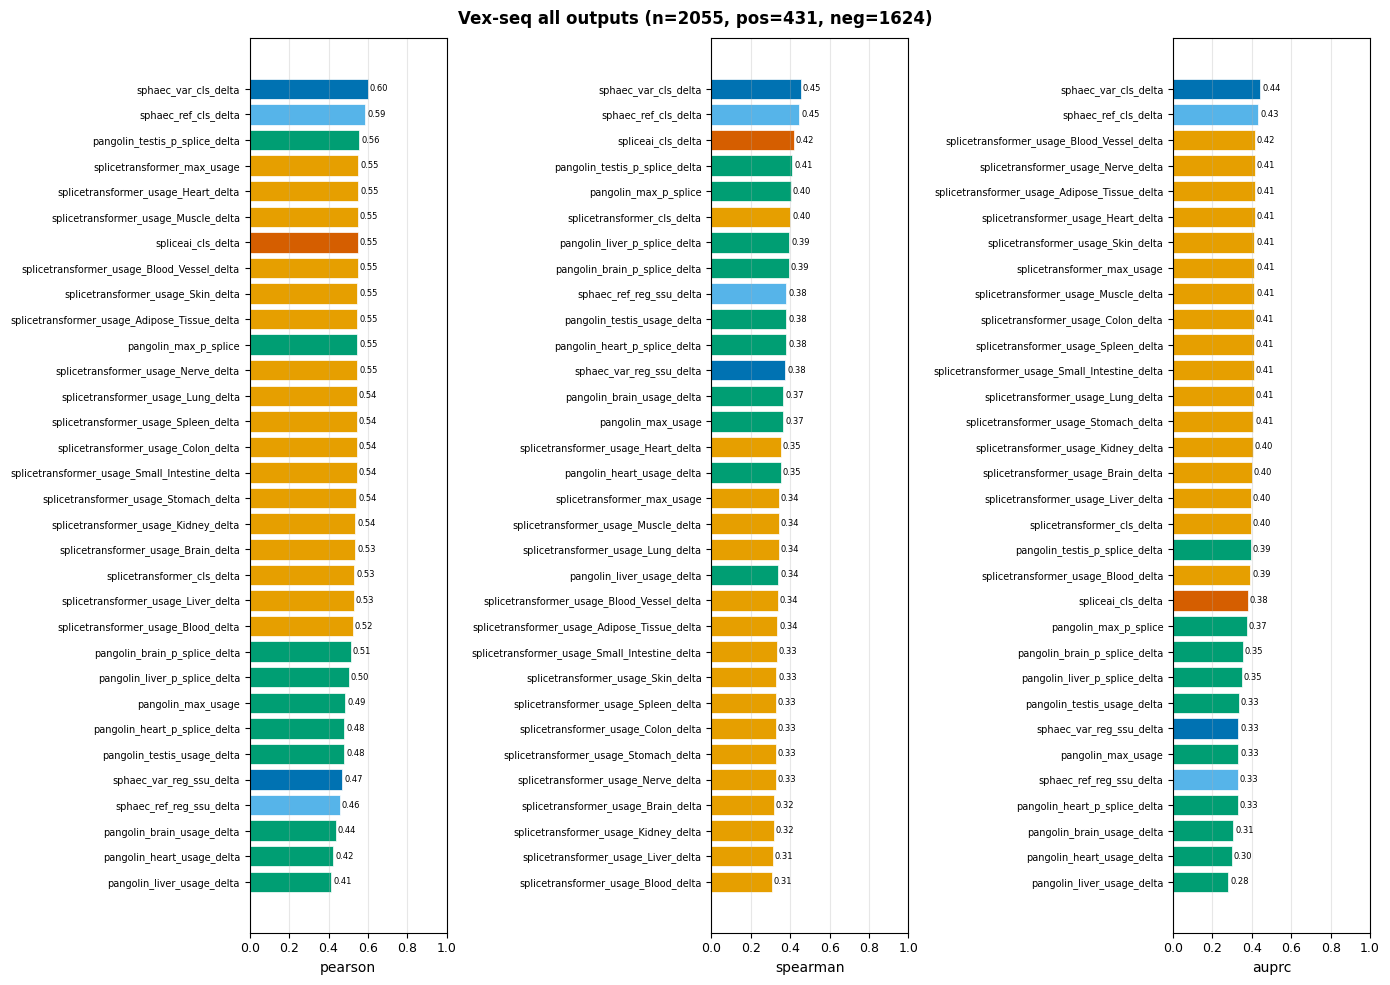


MFASS (n=27733, pos=1050, neg=26683)
column                                           pearson   spearman      auprc
--------------------------------------------------------------------------------
pangolin_max_p_splice                              0.538      0.188      0.466
pangolin_max_usage                                 0.539      0.203      0.456
pangolin_testis_p_splice_delta                     0.507      0.167      0.451
pangolin_heart_p_splice_delta                      0.521      0.183      0.450
pangolin_testis_usage_delta                        0.521      0.194      0.446
pangolin_liver_p_splice_delta                      0.514      0.184      0.444
pangolin_brain_p_splice_delta                      0.515      0.182      0.440
spliceai_cls_delta                                 0.522      0.231      0.437
pangolin_heart_usage_delta                         0.507      0.192      0.422
pangolin_brain_usage_delta                         0.511      0.203      0.421
sphaec_ref_c

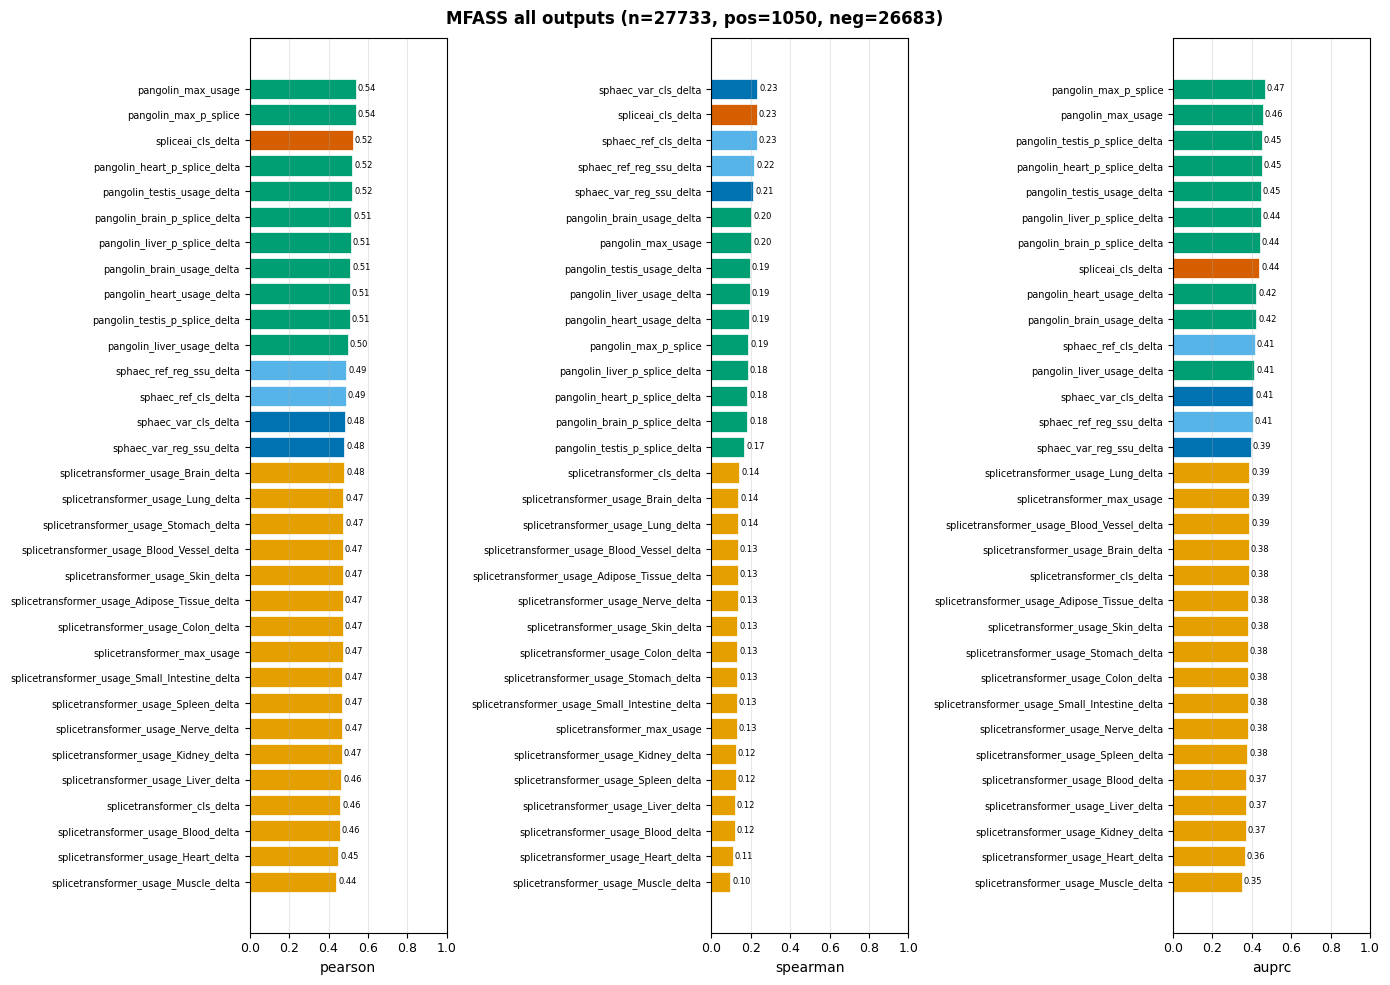

In [45]:
# horizontal bar charts for all outputs
combined_cols = [
    "pangolin_brain_p_splice_delta", "pangolin_brain_usage_delta",
    "pangolin_heart_p_splice_delta", "pangolin_heart_usage_delta",
    "pangolin_liver_p_splice_delta", "pangolin_liver_usage_delta",
    "pangolin_testis_p_splice_delta", "pangolin_testis_usage_delta",
    "pangolin_max_p_splice", "pangolin_max_usage",
    "sphaec_ref_cls_delta", "sphaec_ref_reg_ssu_delta",
    "sphaec_var_cls_delta", "sphaec_var_reg_ssu_delta",
    "spliceai_cls_delta", "splicetransformer_cls_delta",
    "splicetransformer_max_usage",
    "splicetransformer_usage_Adipose_Tissue_delta", "splicetransformer_usage_Blood_Vessel_delta",
    "splicetransformer_usage_Blood_delta", "splicetransformer_usage_Brain_delta",
    "splicetransformer_usage_Colon_delta", "splicetransformer_usage_Heart_delta",
    "splicetransformer_usage_Kidney_delta", "splicetransformer_usage_Liver_delta",
    "splicetransformer_usage_Lung_delta", "splicetransformer_usage_Muscle_delta",
    "splicetransformer_usage_Nerve_delta", "splicetransformer_usage_Skin_delta",
    "splicetransformer_usage_Small_Intestine_delta", "splicetransformer_usage_Spleen_delta",
    "splicetransformer_usage_Stomach_delta",
]

for name, df in dfs.items():
    y, label = df["y"].values, df["label"].values
    n_pos, n_neg = label.sum(), (1 - label).sum()

    results = []
    for col in combined_cols:
        if col not in df.columns:
            continue
        r, rho, auprc = get_metrics(y, df[col].values, label)
        model = col.split("_")[0]
        if "sphaec" in col:
            model = "sphaec_ref" if "ref" in col else "sphaec_var"
        results.append({"col": col, "model": model, "pearson": r, "spearman": rho, "auprc": auprc})

    results_df = pd.DataFrame(results)

    print(f"\n{'='*80}")
    print(f"{dataset_names[name]} (n={len(df)}, pos={n_pos}, neg={n_neg})")
    print(f"{'='*80}")
    print(f"{'column':<45} {'pearson':>10} {'spearman':>10} {'auprc':>10}")
    print("-" * 80)
    for _, row in results_df.sort_values("auprc", ascending=False).iterrows():
        print(f"{row['col']:<45} {row['pearson']:>10.3f} {row['spearman']:>10.3f} {row['auprc']:>10.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(14, 10))

    for ax, metric in zip(axes, ["pearson", "spearman", "auprc"]):
        sorted_df = results_df.sort_values(metric, ascending=True)
        colors = [get_color(row["model"]) for _, row in sorted_df.iterrows()]
        y_pos = np.arange(len(sorted_df))

        ax.barh(y_pos, sorted_df[metric], color=colors, edgecolor="white", linewidth=0.5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(sorted_df["col"], fontsize=7)
        ax.set_xlabel(metric)
        ax.set_xlim(0, 1)
        ax.grid(axis="x", alpha=0.3)

        for i, v in enumerate(sorted_df[metric]):
            if np.isfinite(v):
                ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=6)

    plt.suptitle(f"{dataset_names[name]} all outputs (n={len(df)}, pos={n_pos}, neg={n_neg})", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{out_dir}/{name}_all_outputs.png")
    plt.savefig(f"{out_dir}/{name}_all_outputs.pdf")
    plt.show()

### Precision-recall curves

Shown first for all variants then split by exonic and intronic variants, AUPRC in legend.

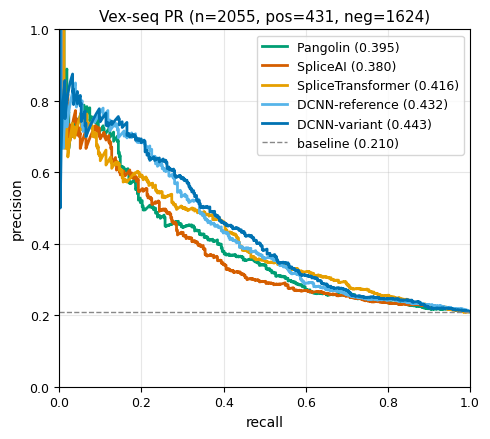

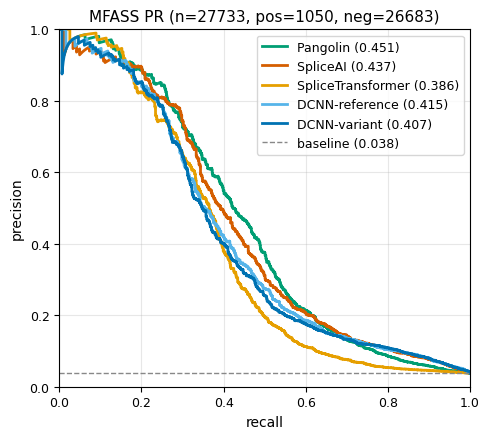

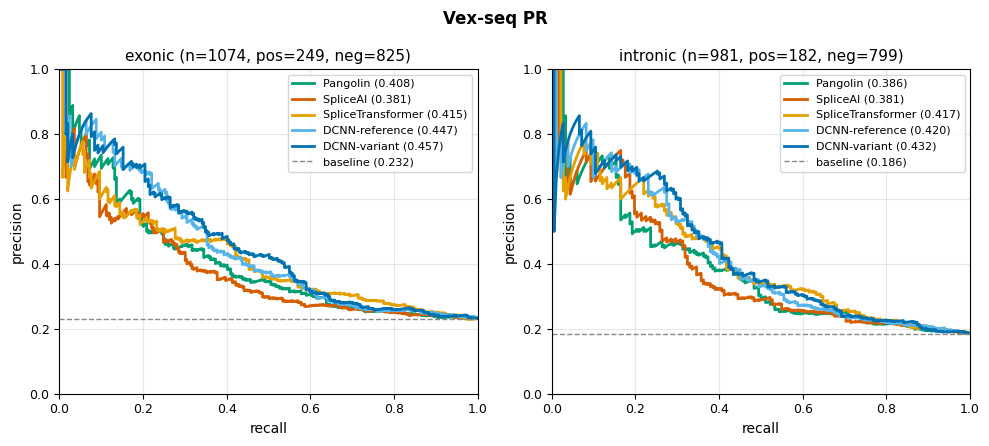

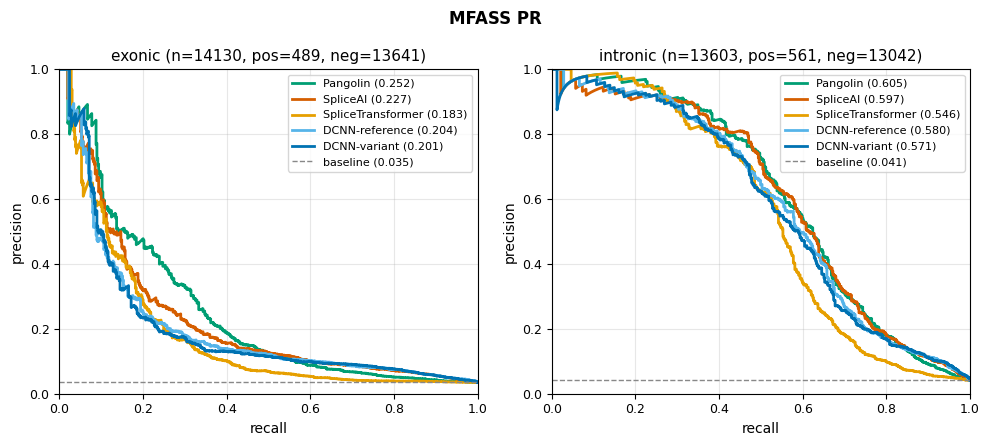

In [46]:
# precision-recall curves - best AUPRC output per model
pr_cols = {
    "vexseq": {
        "pangolin": "pangolin_testis_p_splice_delta",
        "spliceai": "spliceai_cls_delta",
        "splicetransformer": "splicetransformer_usage_Blood_Vessel_delta",
        "sphaec_ref": "sphaec_ref_cls_delta",
        "sphaec_var": "sphaec_var_cls_delta",
    },
    "mfass": {
        "pangolin": "pangolin_testis_p_splice_delta",
        "spliceai": "spliceai_cls_delta",
        "splicetransformer": "splicetransformer_usage_Lung_delta",
        "sphaec_ref": "sphaec_ref_cls_delta",
        "sphaec_var": "sphaec_var_cls_delta",
    },
}

for name, df in dfs.items():
    cols = pr_cols[name]
    label = df["label"].values
    n_pos, n_neg = label.sum(), (1 - label).sum()

    fig, ax = plt.subplots(figsize=(5, 4.5))

    for m in models:
        if cols[m] not in df.columns: continue
        delta = df[cols[m]].values
        prec, rec, _ = precision_recall_curve(label, np.abs(delta))
        auprc = average_precision_score(label, np.abs(delta))
        ax.plot(rec, prec, color=get_color(m), lw=2, label=f"{model_names[m]} ({auprc:.3f})")

    baseline = label.mean()
    ax.axhline(baseline, color="#888888", ls="--", lw=1, label=f"baseline ({baseline:.3f})")
    ax.set_xlabel("recall")
    ax.set_ylabel("precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"{dataset_names[name]} PR (n={len(df)}, pos={n_pos}, neg={n_neg})")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{out_dir}/{name}_pr.png")
    plt.savefig(f"{out_dir}/{name}_pr.pdf")
    plt.show()

# pr curves split by exonic vs intronic
for name, df in dfs.items():
    cols = pr_cols[name]
    pos = df["pos"].values
    exonic = (pos >= df["exon_start"].values) & (pos <= df["exon_end"].values)
    intronic = ~exonic

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

    for ax, (loc_name, mask) in zip(axes, [("exonic", exonic), ("intronic", intronic)]):
        label = df["label"].values[mask]
        n_pos, n_neg = label.sum(), (1 - label).sum()

        for m in models:
            if cols[m] not in df.columns: continue
            delta = df[cols[m]].values[mask]
            if label.sum() == 0: continue
            prec, rec, _ = precision_recall_curve(label, np.abs(delta))
            auprc = average_precision_score(label, np.abs(delta))
            ax.plot(rec, prec, color=get_color(m), lw=2, label=f"{model_names[m]} ({auprc:.3f})")

        baseline = label.mean() if len(label) > 0 else 0
        ax.axhline(baseline, color="#888888", ls="--", lw=1, label=f"baseline ({baseline:.3f})")
        ax.set_xlabel("recall")
        ax.set_ylabel("precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_title(f"{loc_name} (n={mask.sum()}, pos={n_pos}, neg={n_neg})")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(alpha=0.3)

    plt.suptitle(f"{dataset_names[name]} PR", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{out_dir}/{name}_pr_by_location.png")
    plt.savefig(f"{out_dir}/{name}_pr_by_location.pdf")
    plt.show()

### Threshold sensitivity

The AUPRC depends on how we define a splice-disrupting variant. Sweep the delta-PSI threshold and calculate AUPRC and positive and negtive counts.

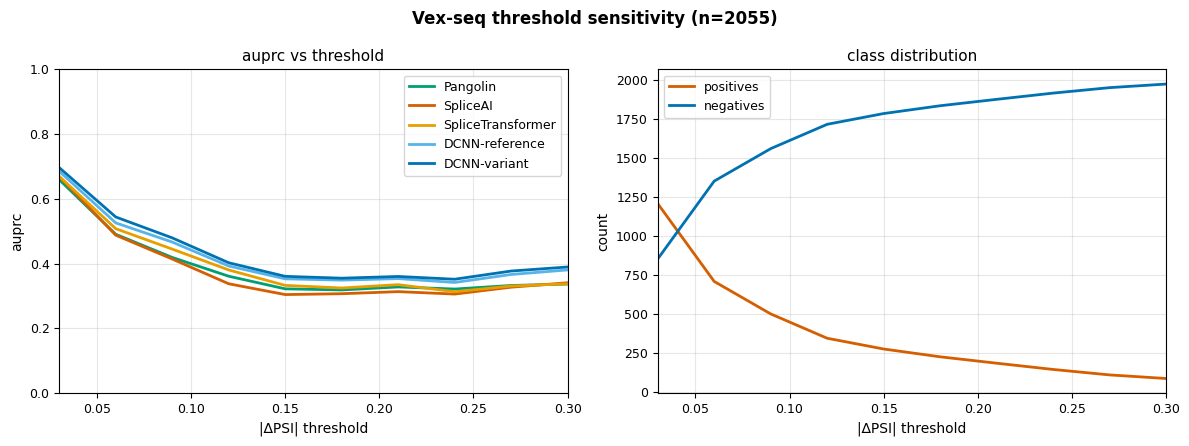

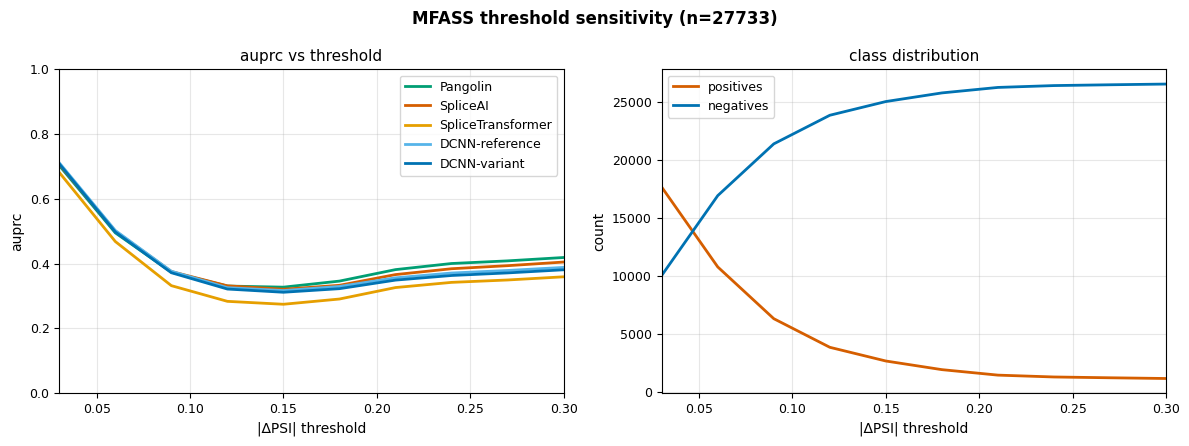

In [47]:
# threshold sensitivity
thresh_cols = {
    "vexseq": {
        "pangolin": "pangolin_testis_p_splice_delta",
        "spliceai": "spliceai_cls_delta",
        "splicetransformer": "splicetransformer_usage_Blood_Vessel_delta",
        "sphaec_ref": "sphaec_ref_cls_delta",
        "sphaec_var": "sphaec_var_cls_delta",
    },
    "mfass": {
        "pangolin": "pangolin_testis_p_splice_delta",
        "spliceai": "spliceai_cls_delta",
        "splicetransformer": "splicetransformer_usage_Lung_delta",
        "sphaec_ref": "sphaec_ref_cls_delta",
        "sphaec_var": "sphaec_var_cls_delta",
    },
}

for name, df in dfs.items():
    cols = thresh_cols[name]
    thresholds = np.linspace(0.03, 0.30, 10)
    y = df["y"].values

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    ax = axes[0]
    for m in models:
        if cols[m] not in df.columns: continue
        delta = df[cols[m]].values
        auprcs = []
        for thr in thresholds:
            lab = (np.abs(y) > thr).astype(int)
            auprcs.append(average_precision_score(lab, np.abs(delta)) if lab.sum() > 0 else np.nan)
        ax.plot(thresholds, auprcs, lw=2, color=get_color(m), label=model_names[m])
    ax.set_xlabel("|\u2206PSI| threshold")
    ax.set_ylabel("auprc")
    ax.set_xlim(thresholds[0], thresholds[-1])
    ax.set_ylim(0, 1)
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_title("auprc vs threshold")

    ax2 = axes[1]
    n_pos = [(np.abs(y) > thr).sum() for thr in thresholds]
    n_neg = [(np.abs(y) <= thr).sum() for thr in thresholds]
    ax2.plot(thresholds, n_pos, lw=2, color="#D55E00", label="positives")
    ax2.plot(thresholds, n_neg, lw=2, color="#0072B2", label="negatives")
    ax2.set_xlabel("|\u2206PSI| threshold")
    ax2.set_ylabel("count")
    ax2.set_xlim(thresholds[0], thresholds[-1])
    ax2.legend(loc="best", fontsize=9)
    ax2.grid(alpha=0.3)
    ax2.set_title("class distribution")

    plt.suptitle(f"{dataset_names[name]} threshold sensitivity (n={len(df)})", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{out_dir}/{name}_threshold.png")
    plt.savefig(f"{out_dir}/{name}_threshold.pdf")
    plt.show()

## Supplemental Figures

Horizontal bar charts, bar comparisons, PR curves, and threshold sensitivity plots for all model outputs.

In [ ]:
# horizontal bar charts for all outputs
combined_cols = [
    "pangolin_brain_p_splice_delta", "pangolin_brain_usage_delta",
    "pangolin_heart_p_splice_delta", "pangolin_heart_usage_delta",
    "pangolin_liver_p_splice_delta", "pangolin_liver_usage_delta",
    "pangolin_testis_p_splice_delta", "pangolin_testis_usage_delta",
    "pangolin_max_p_splice", "pangolin_max_usage",
    "sphaec_ref_cls_delta", "sphaec_ref_reg_ssu_delta",
    "sphaec_var_cls_delta", "sphaec_var_reg_ssu_delta",
    "spliceai_cls_delta", "splicetransformer_cls_delta",
    "splicetransformer_max_usage",
    "splicetransformer_usage_Adipose_Tissue_delta", "splicetransformer_usage_Blood_Vessel_delta",
    "splicetransformer_usage_Blood_delta", "splicetransformer_usage_Brain_delta",
    "splicetransformer_usage_Colon_delta", "splicetransformer_usage_Heart_delta",
    "splicetransformer_usage_Kidney_delta", "splicetransformer_usage_Liver_delta",
    "splicetransformer_usage_Lung_delta", "splicetransformer_usage_Muscle_delta",
    "splicetransformer_usage_Nerve_delta", "splicetransformer_usage_Skin_delta",
    "splicetransformer_usage_Small_Intestine_delta", "splicetransformer_usage_Spleen_delta",
    "splicetransformer_usage_Stomach_delta",
]

# map raw column names to display names
def col_display(c):
    """pretty name for delta column"""
    # strip _delta suffix, re-add as title case at end
    has_delta = c.endswith('_delta')
    base = c.replace('_delta', '') if has_delta else c
    suffix = ' Delta' if has_delta else ''
    # SPLAIRE
    if base == 'sphaec_ref_cls': return f'SPLAIRE CLS{suffix}'
    if base == 'sphaec_ref_reg_ssu': return f'SPLAIRE SSU{suffix}'
    if base == 'sphaec_var_cls': return f'SPLAIRE-var CLS{suffix}'
    if base == 'sphaec_var_reg_ssu': return f'SPLAIRE-var SSU{suffix}'
    # SpliceAI
    if base == 'spliceai_cls': return f'SpliceAI CLS{suffix}'
    # SpliceTransformer
    if base == 'splicetransformer_cls': return f'SpliceTransformer CLS{suffix}'
    if base == 'splicetransformer_max_usage': return f'SpliceTransformer Max Usage{suffix}'
    if base.startswith('splicetransformer_usage_'):
        tissue = base.replace('splicetransformer_usage_', '').replace('_', ' ')
        return f'SpliceTransformer {tissue}{suffix}'
    # Pangolin
    if base.startswith('pangolin_'):
        rest = base.replace('pangolin_', '')
        if rest.endswith('_p_splice'):
            tissue = rest.replace('_p_splice', '').replace('_', ' ').title()
            return f'Pangolin {tissue} CLS{suffix}'
        if rest.endswith('_usage'):
            tissue = rest.replace('_usage', '').replace('_', ' ').title()
            return f'Pangolin {tissue} Usage{suffix}'
        return f'Pangolin {rest.replace("_", " ").title()}{suffix}'
    return c


for name, df in dfs.items():
    y, label = df["y"].values, df["label"].values
    n_pos, n_neg = label.sum(), (1 - label).sum()
    
    # compute metrics
    results = []
    for col in combined_cols:
        if col not in df.columns:
            continue
        r, rho, auprc = get_metrics(y, df[col].values, label)
        model = col.split("_")[0]
        if "sphaec" in col:
            model = "sphaec_ref" if "ref" in col else "sphaec_var"
        results.append({"col": col, "model": model, "pearson": r, "spearman": rho, "auprc": auprc})
    
    results_df = pd.DataFrame(results)
    
    # print results table
    print(f"\n{'='*80}")
    print(f"{dataset_names[name]} (n={len(df)}, pos={n_pos}, neg={n_neg})")
    print(f"{'='*80}")
    print(f"{'column':<45} {'pearson':>10} {'spearman':>10} {'auprc':>10} ")
    print("-" * 80)
    for _, row in results_df.sort_values("auprc", ascending=False).iterrows():
        print(f"{col_display(row['col']):<45} {row['pearson']:>10.3f} {row['spearman']:>10.3f} {row['auprc']:>10.3f}")
    
    # separate figure per metric
    for metric in ["pearson", "spearman", "auprc"]:
        sorted_df = results_df.sort_values(metric, ascending=True)
        colors_bar = [get_color(row["model"]) for _, row in sorted_df.iterrows()]
        y_pos = np.arange(len(sorted_df))
        
        fig, ax = plt.subplots(1, 1, figsize=(7, 12))
        ax.barh(y_pos, sorted_df[metric], color=colors_bar, edgecolor="white", linewidth=0.5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels([col_display(c) for c in sorted_df["col"]])
        ax.set_xlabel(metric.capitalize())
        ax.set_xlim(0, 1)
        ax.grid(axis="x", alpha=0.3)
        
        for i, v in enumerate(sorted_df[metric]):
            if np.isfinite(v):
                ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=ANNOT_SIZE)
        
        ax.set_title(f"{dataset_names[name]} — {metric.capitalize()}")
        plt.tight_layout()
        plt.savefig(f"{fig3_sup}/{name}_{metric}.png", dpi=300)
        plt.show()

In [ ]:
# bar comparison plots - one consistent output per model
bar_cols = {
    "pangolin": "pangolin_max_p_splice",
    "pangolin_usage": "pangolin_max_usage",
    "spliceai": "spliceai_cls_delta",
    "splicetransformer": "splicetransformer_cls_delta",
    "splicetransformer_usage": "splicetransformer_max_usage",
    "sphaec_ref": "sphaec_ref_cls_delta",
    "sphaec_var": "sphaec_var_cls_delta",
}
bar_models = ["pangolin", "pangolin_usage", "spliceai", "splicetransformer", "splicetransformer_usage", "sphaec_ref", "sphaec_var"]

for name, df in dfs.items():
    y, label = df["y"].values, df["label"].values
    n_pos, n_neg = label.sum(), (1 - label).sum()
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 6))
    mods = [m for m in bar_models if bar_cols[m] in df.columns]
    
    for ax, (metric, ylabel) in zip(axes, [("pearson", "Pearson"), ("spearman", "Spearman"), ("auprc", "AUPRC"), ]):
        cols = bar_cols
        vals = []
        for m in mods:
            r, rho, auprc = get_metrics(y, df[cols[m]].values, label)
            if metric == "pearson": vals.append(r)
            elif metric == "spearman": vals.append(rho)
            else: vals.append(auprc)
        
        x = np.arange(len(mods))
        bars = ax.bar(x, vals, color=[get_color(m) for m in mods], edgecolor="white", linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels([model_names[m] for m in mods], rotation=45, ha="right")
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 1)
        ax.grid(axis="y", alpha=0.3)
        for bar, v in zip(bars, vals):
            if np.isfinite(v): ax.text(bar.get_x() + bar.get_width()/2, v * 0.5, f"{v:.2f}", ha="center", va="center", rotation=90, color="white", fontweight="bold")
    
    plt.suptitle(f"{dataset_names[name]} (n={len(df)}, pos={n_pos}, neg={n_neg})", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{fig3_sup}/{name}_comparison.png", dpi=300)
    plt.show()

In [ ]:
# PR curves - same outputs for all datasets
pr_cols = {
    "pangolin": "pangolin_max_p_splice",
    "pangolin_usage": "pangolin_max_usage",
    "spliceai": "spliceai_cls_delta",
    "splicetransformer": "splicetransformer_cls_delta",
    "splicetransformer_usage": "splicetransformer_max_usage",
    "sphaec_ref": "sphaec_ref_cls_delta",
    "sphaec_var": "sphaec_var_cls_delta",
}
pr_models = ["pangolin", "pangolin_usage", "spliceai", "splicetransformer", "splicetransformer_usage", "sphaec_ref", "sphaec_var"]

for name, df in dfs.items():
    cols = pr_cols
    label = df["label"].values
    n_pos, n_neg = label.sum(), (1 - label).sum()
    
    fig, ax = plt.subplots(figsize=(5, 4.5))
    
    for m in pr_models:
        if cols[m] not in df.columns: continue
        delta = df[cols[m]].values
        prec, rec, _ = precision_recall_curve(label, np.abs(delta))
        auprc = average_precision_score(label, np.abs(delta))
        ax.plot(rec, prec, color=get_color(m), lw=2, label=f"{model_names[m]} ({auprc:.3f})")
    
    baseline = label.mean()
    ax.axhline(baseline, color=GRAY_LIGHT, ls="--", lw=1, label=f"baseline ({baseline:.3f})")
    ax.set_xlabel("recall")
    ax.set_ylabel("precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"{dataset_names[name]} PR (n={len(df)}, pos={n_pos}, neg={n_neg})")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{fig3_sup}/{name}_pr.png", dpi=300)
    plt.show()

# pr curves split by exonic vs intronic
for name, df in dfs.items():
    cols = pr_cols
    pos = df["pos"].values
    exonic = (pos >= df["exon_start"].values) & (pos <= df["exon_end"].values)
    intronic = ~exonic
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    
    for ax, (loc_name, mask) in zip(axes, [("exonic", exonic), ("intronic", intronic)]):
        label = df["label"].values[mask]
        n_pos, n_neg = label.sum(), (1 - label).sum()
        
        for m in pr_models:
            if cols[m] not in df.columns: continue
            delta = df[cols[m]].values[mask]
            if label.sum() == 0: continue
            prec, rec, _ = precision_recall_curve(label, np.abs(delta))
            auprc = average_precision_score(label, np.abs(delta))
            ax.plot(rec, prec, color=get_color(m), lw=2, label=f"{model_names[m]} ({auprc:.3f})")
        
        baseline = label.mean() if len(label) > 0 else 0
        ax.axhline(baseline, color=GRAY_LIGHT, ls="--", lw=1, label=f"baseline ({baseline:.3f})")
        ax.set_xlabel("recall")
        ax.set_ylabel("precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_title(f"{loc_name} (n={mask.sum()}, pos={n_pos}, neg={n_neg})")
        ax.legend(loc="upper right")
        ax.grid(alpha=0.3)
    
    plt.suptitle(f"{dataset_names[name]} PR", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{fig3_sup}/{name}_pr_by_location.png", dpi=300)
    plt.show()

In [ ]:
# threshold sensitivity
thresh_cols = {
    "pangolin": "pangolin_max_p_splice",
    "spliceai": "spliceai_cls_delta",
    "splicetransformer": "splicetransformer_cls_delta",
    "sphaec_ref": "sphaec_ref_cls_delta",
    "sphaec_var": "sphaec_var_cls_delta",
}
thresh_models = ["pangolin", "spliceai", "splicetransformer", "sphaec_ref", "sphaec_var"]

for name, df in dfs.items():
    cols = thresh_cols
    thresholds = np.arange(0, 1.01, 0.01)
    y = df["y"].values
    
    fig, axes = plt.subplots(2, 1, figsize=(6, 9))
    
    ax = axes[0]
    for m in thresh_models:
        if cols[m] not in df.columns: continue
        delta = df[cols[m]].values
        auprcs = []
        for thr in thresholds:
            lab = (np.abs(y) > thr).astype(int)
            auprcs.append(average_precision_score(lab, np.abs(delta)) if lab.sum() > 0 else np.nan)
        ax.plot(thresholds, auprcs, lw=2, color=get_color(m), label=model_names[m])
    ax.set_xlabel("|ΔPSI| threshold")
    ax.set_ylabel("AUPRC")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    ax.set_title("AUPRC vs threshold")
    
    ax2 = axes[1]
    n_pos = [(np.abs(y) > thr).sum() for thr in thresholds]
    n_neg = [(np.abs(y) <= thr).sum() for thr in thresholds]
    ax2.plot(thresholds, n_pos, lw=2, color="#D55E00", label="positives")
    ax2.plot(thresholds, n_neg, lw=2, color="#0072B2", label="negatives")
    ax2.set_xlabel("|ΔPSI| threshold")
    ax2.set_ylabel("count")
    ax2.set_xlim(0, 1)
    ax2.legend(loc="best")
    ax2.grid(alpha=0.3)
    ax2.set_title("class distribution")
    
    plt.suptitle(f"{dataset_names[name]} threshold sensitivity (n={len(df):,})", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{fig3_sup}/{name}_threshold.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"saved {fig3_sup}/{name}_threshold.png")

## Bootstrap Significance Testing

Paired bootstrap resampling (n=10,000) for statistical comparison of model performance.


In [ ]:
# 1-SD filtering — classify variants as splice-altering or neutral
# following Mount et al. 2019 (CAGI5)

sd_info = {}
for name, df in dfs.items():
    y = df["y"].values
    y_clean = y[np.isfinite(y)]
    mu, sd = y_clean.mean(), y_clean.std()
    lo, hi = mu - sd, mu + sd
    outside = (y_clean < lo) | (y_clean > hi)
    n_pos = (y_clean > hi).sum()
    n_neg = (y_clean < lo).sum()
    n_neutral = (~outside).sum()
    sd_info[name] = (mu, sd, lo, hi)
    print(f"{dataset_names[name]}:")
    print(f"  mean = {mu:.4f}, SD = {sd:.4f}")
    print(f"  thresholds: < {lo:.4f} (decreasing) or > {hi:.4f} (increasing)")
    print(f"  kept: {n_pos + n_neg:,} / {len(y_clean):,} ({100*(n_pos+n_neg)/len(y_clean):.1f}%)")

# filter dataframes
dfs_filt = {}
for name, df in dfs.items():
    mu, sd, lo, hi = sd_info[name]
    mask = (df["y"] < lo) | (df["y"] > hi)
    dfs_filt[name] = df[mask].reset_index(drop=True)
    print(f"{dataset_names[name]} filtered: {len(dfs_filt[name]):,} variants")

# neutral dataframes (within ±1 SD) for gray background scatter
dfs_neutral = {}
for name, df in dfs.items():
    mu, sd, lo, hi = sd_info[name]
    mask = (df["y"] >= lo) & (df["y"] <= hi)
    dfs_neutral[name] = df[mask].reset_index(drop=True)


In [ ]:
# save filtered data for figures.ipynb
# (avoids re-running full H5 loading + delta computation in the figures notebook)
import pickle

_reporter_pkl = fig3_main / "_reporter_data.pkl"
_reporter_data = {
    "dfs_filt": dfs_filt,
    "dfs_neutral": dfs_neutral,
}
with open(_reporter_pkl, "wb") as f:
    pickle.dump(_reporter_data, f)
print(f"saved reporter data to {_reporter_pkl}")
for name, df in dfs_filt.items():
    print(f"  {dataset_names[name]}: {len(df):,} filtered, {len(dfs_neutral[name]):,} neutral")


In [ ]:
def bootstrap_compare(y, preds_dict, label, n_boot=10_000, seed=42):
    """paired bootstrap significance for all model pairs, returns results dict"""
    from itertools import combinations
    from sklearn.metrics import r2_score

    models = list(preds_dict.keys())
    n = len(y)

    # all predictions must be finite
    for m, pred in preds_dict.items():
        n_nonfinite = (~np.isfinite(pred)).sum()
        if n_nonfinite > 0:
            raise ValueError(f"model {m} has {n_nonfinite} non-finite predictions")
    if (~np.isfinite(y)).any():
        raise ValueError(f"y has {(~np.isfinite(y)).sum()} non-finite values")
    n_m = len(y)
    y_m, lab_m = y, label
    preds_m = preds_dict
    if n_m < 10:
        return {}

    rng = np.random.default_rng(seed)

    # bootstrap: compute metrics for each model on each resample
    # store as {model: (n_boot, 4)} array — columns: pearson, spearman, r2, auprc
    boot_metrics = {m: np.empty((n_boot, 4)) for m in models}

    for b in range(n_boot):
        idx = rng.choice(n_m, size=n_m, replace=True)
        yb, lb = y_m[idx], lab_m[idx]
        for m in models:
            pb = preds_m[m][idx]
            r = stats.pearsonr(yb, pb)[0]
            rho = stats.spearmanr(yb, pb)[0]
            r2 = r2_score(yb, pb)
            auprc = average_precision_score(lb, np.abs(pb)) if lb.sum() > 0 else np.nan
            boot_metrics[m][b] = [r, rho, r2, auprc]

    metric_names = ["Pearson", "Spearman", "R2", "AUPRC"]
    results = {}
    for a, b in combinations(models, 2):
        results[(a, b)] = {}
        for mi, mname in enumerate(metric_names):
            diff = boot_metrics[a][:, mi] - boot_metrics[b][:, mi]
            p_left = np.mean(diff <= 0)
            p_val = 2 * min(p_left, 1 - p_left)
            p_val = min(p_val, 1.0)
            results[(a, b)][mname] = {
                "diff_mean": np.mean(diff),
                "ci_lo": np.percentile(diff, 2.5),
                "ci_hi": np.percentile(diff, 97.5),
                "p": p_val,
            }
    return results

def cluster_bootstrap_compare(y, preds_dict, label, clusters, n_boot=10_000, seed=42):
    """cluster bootstrap: resample exons (clusters) instead of individual variants"""
    from itertools import combinations
    from sklearn.metrics import r2_score

    models = list(preds_dict.keys())

    # all predictions must be finite
    for m, pred in preds_dict.items():
        n_nonfinite = (~np.isfinite(pred)).sum()
        if n_nonfinite > 0:
            raise ValueError(f"model {m} has {n_nonfinite} non-finite predictions")
    if (~np.isfinite(y)).any():
        raise ValueError(f"y has {(~np.isfinite(y)).sum()} non-finite values")
    n = len(y)
    if n < 10:
        return {}

    # group indices by cluster
    unique_clusters = np.unique(clusters)
    cluster_idx = {c: np.where(clusters == c)[0] for c in unique_clusters}
    n_clusters = len(unique_clusters)
    print(f"  cluster bootstrap: {n} variants in {n_clusters} clusters")

    rng = np.random.default_rng(seed)
    boot_metrics = {m: np.empty((n_boot, 4)) for m in models}

    for b in range(n_boot):
        sampled = rng.choice(unique_clusters, size=n_clusters, replace=True)
        idx = np.concatenate([cluster_idx[c] for c in sampled])
        yb, lb = y[idx], label[idx]
        for m in models:
            pb = preds_dict[m][idx]
            r = stats.pearsonr(yb, pb)[0]
            rho = stats.spearmanr(yb, pb)[0]
            r2 = r2_score(yb, pb)
            auprc = average_precision_score(lb, np.abs(pb)) if lb.sum() > 0 else np.nan
            boot_metrics[m][b] = [r, rho, r2, auprc]

    metric_names = ["Pearson", "Spearman", "R2", "AUPRC"]
    results = {}
    for a, b_ in combinations(models, 2):
        results[(a, b_)] = {}
        for mi, mname in enumerate(metric_names):
            diff = boot_metrics[a][:, mi] - boot_metrics[b_][:, mi]
            p_left = np.mean(diff <= 0)
            p_val = 2 * min(p_left, 1 - p_left)
            p_val = min(p_val, 1.0)
            results[(a, b_)][mname] = {
                "diff_mean": np.mean(diff),
                "ci_lo": np.percentile(diff, 2.5),
                "ci_hi": np.percentile(diff, 97.5),
                "p": p_val,
            }
    return results


def holm_bonferroni(results):
    """apply holm-bonferroni correction per metric (separate family per metric)"""
    # group p-values by metric
    by_metric = {}
    for pair, metrics in results.items():
        for mname, d in metrics.items():
            by_metric.setdefault(mname, []).append((pair, d["p"]))
    # correct within each metric family
    for mname, pvals in by_metric.items():
        pvals.sort(key=lambda x: x[1])
        k = len(pvals)
        prev = 0.0
        for i, (pair, p) in enumerate(pvals):
            p_adj = min(max(prev, p * (k - i)), 1.0)
            prev = p_adj
            results[pair][mname]["p_adj_holm_k10"] = p_adj
            results[pair][mname]["sig_holm_k10"] = significance_stars(p_adj)


def significance_stars(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return ""


def get_boot_sig(results, a, b, metric):
    """look up pairwise significance, handles reversed pair order"""
    if (a, b) in results:
        return results[(a, b)].get(metric)
    elif (b, a) in results:
        d = results[(b, a)].get(metric)
        if d is None:
            return None
        return {"diff_mean": -d["diff_mean"], "ci_lo": -d["ci_hi"], "ci_hi": -d["ci_lo"],
                "p": d["p"],
                "p_adj_holm_k10": d.get("p_adj_holm_k10", d["p"]),
                "sig_holm_k10": d.get("sig_holm_k10", "")}
    return None


def print_bootstrap_table(results, model_names_map, title):
    """print formatted comparison table"""
    if not results:
        print(f"{title}: insufficient data")
        return
    metric_names = ["Pearson", "Spearman", "R2", "AUPRC"]
    w = 120
    print(f"\n{'=' * w}")
    print(title)
    print(f"{'=' * w}")
    header = f"{'model A':<20} {'model B':<20}"
    for mn in metric_names:
        header += f" {mn:>8} {'p':>7} {'':>3}"
    print(header)
    print("-" * w)
    for (a, b), metrics in results.items():
        na = model_names_map.get(a, a)
        nb = model_names_map.get(b, b)
        row = f"{na:<20} {nb:<20}"
        for mn in metric_names:
            d = metrics[mn]
            diff_str = f"{d['diff_mean']:+.3f}"
            p_str = f"{d['p_adj_holm_k10']:.4f}" if d['p_adj_holm_k10'] >= 0.0001 else "<.0001"
            sig_str = d['sig_holm_k10']
            row += f" {diff_str:>8} {p_str:>7} {sig_str:>3}"
        print(row)
    print()


def draw_all_sig_brackets(ax, mi, bar_w, n_models, models_avail, model_vals, metric,
                           boot_key, y_offset=0.05, dh=0.04):
    """draw significance brackets for all significant model pairs within one metric group"""
    try:
        boot = _boot_results
    except NameError:
        return 0
    if boot_key not in boot:
        return 0
    pairs = []
    for i in range(len(models_avail)):
        for j in range(i + 1, len(models_avail)):
            a, b = models_avail[i], models_avail[j]
            sig_info = get_boot_sig(boot[boot_key], a, b, metric)
            if sig_info and sig_info.get("sig_holm_k10", ""):
                pairs.append((i, j, sig_info["sig_holm_k10"]))
    if not pairs:
        return 0
    def bar_x(bi):
        return mi + (bi - n_models / 2 + 0.5) * bar_w
    y_base = max(model_vals[m][metric] for m in models_avail) + y_offset
    pairs.sort(key=lambda p: p[1] - p[0])
    for k, (i, j, sig) in enumerate(pairs):
        y = y_base + k * dh
        x1, x2 = bar_x(i), bar_x(j)
        ax.plot([x1, x1, x2, x2], [y - 0.008, y, y, y - 0.008], lw=0.7, color="black", clip_on=False)
        ax.text((x1 + x2) / 2, y + 0.003, sig, ha="center", va="bottom", fontsize=5.5, clip_on=False)
    return len(pairs)


def holm_correct(pvals_list):
    """apply holm-bonferroni to [(label, p), ...], returns {label: (p_adj, sig_str)}"""
    pvals_list.sort(key=lambda x: x[1])
    k = len(pvals_list)
    result = {}
    prev = 0.0
    for i, (label, p) in enumerate(pvals_list):
        p_adj = min(max(prev, p * (k - i)), 1.0)
        prev = p_adj
        result[label] = (p_adj, significance_stars(p_adj))
    return result


def bonferroni_correct_k(results, k):
    """apply plain bonferroni with explicit k (e.g. k=4 for vs-best, k=10 for all-pairs)"""
    for pair, metrics in results.items():
        for mname, d in metrics.items():
            p_adj = min(d["p"] * k, 1.0)
            results[pair][mname][f"p_adj_bonf_k{k}"] = p_adj
            results[pair][mname][f"sig_bonf_k{k}"] = significance_stars(p_adj)


def holm_correct_k(results, k):
    """apply holm step-down with explicit k (e.g. k=4 for vs-best)"""
    by_metric = {}
    for pair, metrics in results.items():
        for mname, d in metrics.items():
            by_metric.setdefault(mname, []).append((pair, d["p"]))
    for mname, pvals in by_metric.items():
        pvals.sort(key=lambda x: x[1])
        prev = 0.0
        for i, (pair, p) in enumerate(pvals):
            p_adj = min(max(prev, p * max(k - i, 1)), 1.0)
            prev = p_adj
            results[pair][mname][f"p_adj_holm_k{k}"] = p_adj
            results[pair][mname][f"sig_holm_k{k}"] = significance_stars(p_adj)


### Statistical Comparison Methods

Variants were classified as splice-altering if |$\Delta$PSI| exceeded 0.1 for Vex-seq or 0.5 for MFASS. Model performance was assessed by comparing measured and predicted $\Delta$PSI using Pearson's correlation, Spearman's correlation, and AUPRC between predicted delta scores and measured $\Delta$PSI.

Bootstrap significance testing uses paired bootstrap resampling (n=10,000, seed=42). In each iteration, variant indices were resampled with replacement and applied identically across all models. Two-sided p-values were calculated as 2 $\times$ min(p\_left, 1 - p\_left). Holm-Bonferroni correction is applied separately within each metric.

In [ ]:
# bootstrap significance testing — reporter assays
# results cached to disk (_boot_results.pkl) + memory

import pickle

_boot_pkl = fig3_main / "_boot_results.pkl"

# load from disk if available, else start fresh
try:
    _boot_results
except NameError:
    if _boot_pkl.exists():
        with open(_boot_pkl, "rb") as f:
            _boot_results = pickle.load(f)
        print(f"loaded {len(_boot_results)} cached results from {_boot_pkl}")
    else:
        _boot_results = {}

_split_cols_boot = {
    "pangolin": "pangolin_max_p_splice",
    "spliceai": "spliceai_cls_delta",
    "splicetransformer": "splicetransformer_cls_delta",
    "sphaec_ref": "sphaec_ref_cls_delta",
    "sphaec_var": "sphaec_var_cls_delta",
}

_n_new = 0
for tag, data_src in [("full", dfs), ("filtered", dfs_filt)]:
    for name, df in data_src.items():
        y = df["y"].values
        label = df["label"].values
        pos = df["pos"].values
        exonic = (pos >= df["exon_start"].values) & (pos <= df["exon_end"].values)
        intronic = ~exonic
        all_mask = np.ones(len(y), dtype=bool)

        preds_dict = {}
        for m, col in _split_cols_boot.items():
            if col in df.columns:
                preds_dict[m] = df[col].values

        # for filtered: combined data for AUPRC (non-neutral=1, neutral=0)
        if tag == "filtered":
            df_neut = dfs_neutral[name]
            df_comb = pd.concat([df.assign(_nonneutral=1), df_neut.assign(_nonneutral=0)], ignore_index=True)
            y_comb = df_comb["y"].values
            label_comb = df_comb["_nonneutral"].values
            pos_comb = df_comb["pos"].values
            exonic_comb = (pos_comb >= df_comb["exon_start"].values) & (pos_comb <= df_comb["exon_end"].values)
            intronic_comb = ~exonic_comb
            all_mask_comb = np.ones(len(y_comb), dtype=bool)
            preds_dict_comb = {}
            for m, col in _split_cols_boot.items():
                if col in df_comb.columns:
                    preds_dict_comb[m] = df_comb[col].values

        for subset_name, mask in [("all", all_mask), ("exonic", exonic), ("intronic", intronic)]:
            key = (name, tag, subset_name)
            if key in _boot_results:
                print(f"cached: {dataset_names[name]} — {tag} — {subset_name}")
                continue

            n_sub = mask.sum()
            title = f"{dataset_names[name]} — {tag} — {subset_name} (n={n_sub:,})"

            if tag == "filtered":
                # pearson/spearman/r2 from filtered data only
                results_corr = bootstrap_compare(
                    y[mask], {m: p[mask] for m, p in preds_dict.items()}, label[mask]
                )
                # auprc from combined data (non-neutral vs neutral)
                mask_comb = {"all": all_mask_comb, "exonic": exonic_comb, "intronic": intronic_comb}[subset_name]
                results_auprc = bootstrap_compare(
                    y_comb[mask_comb], {m: p[mask_comb] for m, p in preds_dict_comb.items()}, label_comb[mask_comb]
                )
                # merge: Pearson/Spearman/R2 from filtered, AUPRC from combined
                results = {}
                for pair in results_corr:
                    results[pair] = {}
                    for metric in ["Pearson", "Spearman", "R2"]:
                        results[pair][metric] = results_corr[pair][metric]
                    if pair in results_auprc:
                        results[pair]["AUPRC"] = results_auprc[pair]["AUPRC"]
            else:
                results = bootstrap_compare(
                    y[mask], {m: p[mask] for m, p in preds_dict.items()}, label[mask]
                )

            if results:
                holm_bonferroni(results)
                _boot_results[key] = results
                _n_new += 1
                print_bootstrap_table(results, model_names, title)

# save to disk if new results were computed
if _n_new > 0:
    with open(_boot_pkl, "wb") as f:
        pickle.dump(_boot_results, f)
    print(f"\nsaved {len(_boot_results)} results to {_boot_pkl} ({_n_new} new)")
else:
    print(f"\nall {len(_boot_results)} results cached, nothing to compute")

# === cluster bootstrap (resample by exon) ===
_cboot_pkl = fig3_main / "_cboot_results.pkl"
try:
    _cboot_results
except NameError:
    if _cboot_pkl.exists():
        with open(_cboot_pkl, "rb") as f:
            _cboot_results = pickle.load(f)
        print(f"loaded {len(_cboot_results)} cached cluster bootstrap results")
    else:
        _cboot_results = {}

_cn_new = 0
for tag, data_src in [("full", dfs), ("filtered", dfs_filt)]:
    for name, df in data_src.items():
        y = df["y"].values
        label = df["label"].values
        pos = df["pos"].values
        exonic = (pos >= df["exon_start"].values) & (pos <= df["exon_end"].values)
        intronic = ~exonic
        all_mask = np.ones(len(y), dtype=bool)
        # cluster ID = exon boundaries
        clusters = (df["exon_start"].astype(str) + "_" + df["exon_end"].astype(str)).values

        preds_dict = {}
        for m, col in _split_cols_boot.items():
            if col in df.columns:
                preds_dict[m] = df[col].values

        if tag == "filtered":
            df_neut = dfs_neutral[name]
            df_comb = pd.concat([df.assign(_nonneutral=1), df_neut.assign(_nonneutral=0)], ignore_index=True)
            y_comb = df_comb["y"].values
            label_comb = df_comb["_nonneutral"].values
            pos_comb = df_comb["pos"].values
            exonic_comb = (pos_comb >= df_comb["exon_start"].values) & (pos_comb <= df_comb["exon_end"].values)
            intronic_comb = ~exonic_comb
            all_mask_comb = np.ones(len(y_comb), dtype=bool)
            clusters_comb = (df_comb["exon_start"].astype(str) + "_" + df_comb["exon_end"].astype(str)).values
            preds_dict_comb = {}
            for m, col in _split_cols_boot.items():
                if col in df_comb.columns:
                    preds_dict_comb[m] = df_comb[col].values

        for subset_name, mask in [("all", all_mask), ("exonic", exonic), ("intronic", intronic)]:
            key = (name, tag, subset_name)
            if key in _cboot_results:
                print(f"cluster cached: {dataset_names[name]} — {tag} — {subset_name}")
                continue

            n_sub = mask.sum()
            title = f"CLUSTER: {dataset_names[name]} — {tag} — {subset_name} (n={n_sub:,})"

            if tag == "filtered":
                results_corr = cluster_bootstrap_compare(
                    y[mask], {m: p[mask] for m, p in preds_dict.items()}, label[mask], clusters[mask]
                )
                mask_comb = {"all": all_mask_comb, "exonic": exonic_comb, "intronic": intronic_comb}[subset_name]
                results_auprc = cluster_bootstrap_compare(
                    y_comb[mask_comb], {m: p[mask_comb] for m, p in preds_dict_comb.items()},
                    label_comb[mask_comb], clusters_comb[mask_comb]
                )
                results = {}
                for pair in results_corr:
                    results[pair] = {}
                    for metric in ["Pearson", "Spearman", "R2"]:
                        results[pair][metric] = results_corr[pair][metric]
                    if pair in results_auprc:
                        results[pair]["AUPRC"] = results_auprc[pair]["AUPRC"]
            else:
                results = cluster_bootstrap_compare(
                    y[mask], {m: p[mask] for m, p in preds_dict.items()}, label[mask], clusters[mask]
                )

            if results:
                holm_bonferroni(results)
                _cboot_results[key] = results
                _cn_new += 1
                print_bootstrap_table(results, model_names, title)

if _cn_new > 0:
    with open(_cboot_pkl, "wb") as f:
        pickle.dump(_cboot_results, f)
    print(f"\nsaved {len(_cboot_results)} cluster results to {_cboot_pkl} ({_cn_new} new)")
else:
    print(f"\nall {len(_cboot_results)} cluster results cached")

# re-apply corrections on cluster results
for key, results in _cboot_results.items():
    holm_bonferroni(results)
    holm_correct_k(results, 4)
    bonferroni_correct_k(results, 4)
    bonferroni_correct_k(results, 10)

# re-apply corrections on all results (handles cached results with stale corrections)
for key, results in _boot_results.items():
    holm_bonferroni(results)        # holm per-metric (k=10 for all-pairs)
    holm_correct_k(results, 4)         # holm per-metric (k=4 for vs-best)
    bonferroni_correct_k(results, 4)   # plain bonferroni vs-best (k=4)
    bonferroni_correct_k(results, 10)  # plain bonferroni all-pairs (k=10)
print("re-applied all corrections (holm k=10, bonferroni k=4, bonferroni k=10)")

# comparison table: holm vs bonferroni
print("\n" + "=" * 90)
print("CORRECTION COMPARISON: Holm k=10 vs Holm k=4 vs Bonferroni k=4 vs Bonferroni k=10")
print("=" * 90)
for key, results in _boot_results.items():
    name, tag, subset = key
    print(f"\n{dataset_names[name]} — {tag} — {subset}")
    print(f"{'pair':<42} {'metric':<10} {'raw p':>8} {'Holm10':>8} {'Holm4':>8} {'Bonf4':>8} {'Bonf10':>8}")
    print("-" * 90)
    for (a, b), metrics in results.items():
        na, nb_ = model_names.get(a, a), model_names.get(b, b)
        for mname, d in metrics.items():
            p_raw = d["p"]
            p_holm = d.get("p_adj_holm_k10", p_raw)
            p_holm4 = d.get("p_adj_holm_k4", p_raw)
            p_b4 = d.get("p_adj_bonf_k4", p_raw)
            p_b10 = d.get("p_adj_bonf_k10", p_raw)
            # only print where any correction differs
            stars = [d.get("sig_holm_k10",""), d.get("sig_holm_k4",""), d.get("sig_bonf_k4",""), d.get("sig_bonf_k10","")]
            if any(s != stars[0] for s in stars) or p_raw < 0.1:
                fmt_p = lambda p: f"{p:.4f}" if p >= 0.0001 else "<.0001"
                print(f"{na:<20} vs {nb_:<17} {mname:<10} {fmt_p(p_raw):>8} {fmt_p(p_holm):>8} {fmt_p(p_holm4):>8} {fmt_p(p_b4):>8} {fmt_p(p_b10):>8}")

# standard vs cluster bootstrap comparison
print("\n" + "=" * 100)
print("STANDARD vs CLUSTER BOOTSTRAP (both Holm k=10)")
print("=" * 100)
for key in _boot_results:
    if key not in _cboot_results:
        continue
    name, tag, subset = key
    std = _boot_results[key]
    clust = _cboot_results[key]
    print(f"\n{dataset_names[name]} — {tag} — {subset}")
    print(f"{'pair':<42} {'metric':<10} {'std p':>8} {'clust p':>8} {'std sig':>8} {'clust sig':>8}")
    print("-" * 85)
    for (a, b_) in std:
        if (a, b_) not in clust:
            continue
        na, nb_ = model_names.get(a, a), model_names.get(b_, b_)
        for mname in std[(a, b_)]:
            if mname not in clust[(a, b_)]:
                continue
            ds = std[(a, b_)][mname]
            dc = clust[(a, b_)][mname]
            fmt_p = lambda p: f"{p:.4f}" if p >= 0.0001 else "<.0001"
            print(f"{na:<20} vs {nb_:<17} {mname:<10} {fmt_p(ds['p']):>8} {fmt_p(dc['p']):>8} {ds.get('sig_holm_k10',''):>8} {dc.get('sig_holm_k10',''):>8}")

## Alternative Figure Variants

Filtered (log density) and unfiltered scatter + grouped bar figures.


In [ ]:
# Option A: scatter + grouped bars by metric — filtered reporter assays

from scipy.stats import spearmanr
from matplotlib.patches import Patch
from sklearn.metrics import average_precision_score

_cols_a = {
    "pangolin": "pangolin_max_p_splice",
    "spliceai": "spliceai_cls_delta",
    "splicetransformer": "splicetransformer_cls_delta",
    "sphaec_ref": "sphaec_ref_cls_delta",
    "sphaec_var": "sphaec_var_cls_delta",
}
_models_a = ["pangolin", "spliceai", "splicetransformer", "sphaec_ref", "sphaec_var"]
_metrics_a = ["Pearson", "Spearman", "AUPRC"]

all_mods_a = set()
for name, df in dfs_filt.items():
    all_mods_a.update(m for m in _models_a if _cols_a[m] in df.columns)
mods_a = [m for m in _models_a if m in all_mods_a]
nm_a = len(mods_a)

_scatter_ticks = [-1, -0.5, 0, 0.5, 1]
n_datasets = len(dfs_filt)

fig = plt.figure(figsize=(3.5 * nm_a, 7 * n_datasets))
gs = fig.add_gridspec(n_datasets * 2, 1, height_ratios=[1, 0.7] * n_datasets, hspace=0.85)

_sc_axes_a = {}
_bar_axes_a = {}
_sc_refs_a = {}

for d_idx, (name, df) in enumerate(dfs_filt.items()):
    df_neut = dfs_neutral[name]
    y, label = df["y"].values, df["label"].values
    pos = df["pos"].values
    exonic = (pos >= df["exon_start"].values) & (pos <= df["exon_end"].values)
    intronic = ~exonic
    all_mask = np.ones(len(df), dtype=bool)

    # === scatter row ===
    gs_sc = gs[d_idx * 2].subgridspec(1, nm_a, wspace=0.3)
    scatter_data = {}
    z_min, z_max = float('inf'), float('-inf')
    for m in mods_a:
        if _cols_a[m] not in df.columns: continue
        xm, ym, z_log, order = _get_kde_filt(name, m, y, df[_cols_a[m]].values)
        scatter_data[m] = (xm, ym, z_log, order)
        z_min = min(z_min, z_log.min())
        z_max = max(z_max, z_log.max())

    sc_ref = None
    sc_axes = []
    for j, m in enumerate(mods_a):
        ax = fig.add_subplot(gs_sc[0, j])
        sc_axes.append(ax)
        if m not in scatter_data:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
            ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
            continue
        # neutral background
        if _cols_a[m] in df_neut.columns:
            yn = df_neut["y"].values; pn = df_neut[_cols_a[m]].values
            fin = np.isfinite(yn) & np.isfinite(pn)
            ax.scatter(yn[fin], pn[fin], c="lightgray", s=8, alpha=0.4, edgecolors="none", zorder=1)
        xm, ym, z_log, order = scatter_data[m]
        sc = ax.scatter(xm[order], ym[order], c=z_log[order], cmap="viridis",
                        s=12, alpha=0.8, edgecolors="none", vmin=z_min, vmax=z_max, zorder=2)
        sc_ref = sc
        r2 = spearmanr(xm, ym)[0] ** 2
        ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}", transform=ax.transAxes, fontsize=ANNOT_SIZE, va="top", ha="left")
        ax.axhline(0, color="gray", ls="--", lw=0.5, alpha=0.5)
        ax.axvline(0, color="gray", ls="--", lw=0.5, alpha=0.5)
        ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect("equal")
        ax.set_xticks(_scatter_ticks); ax.set_yticks(_scatter_ticks)
        if j == 0: ax.set_ylabel("Predicted \u0394PSI")
        else: ax.set_ylabel("")
        ax.set_xlabel("Measured \u0394PSI")
        ax.set_title(model_names[m])
    _sc_axes_a[d_idx] = sc_axes
    _sc_refs_a[d_idx] = sc_ref

    # === grouped bars row ===
    gs_bar = gs[d_idx * 2 + 1].subgridspec(1, 3, wspace=0.3)
    df_comb = pd.concat([df.assign(_nonneutral=1), df_neut.assign(_nonneutral=0)], ignore_index=True)
    pos_comb = df_comb["pos"].values
    exonic_comb = (pos_comb >= df_comb["exon_start"].values) & (pos_comb <= df_comb["exon_end"].values)
    intronic_comb = ~exonic_comb
    all_comb = np.ones(len(df_comb), dtype=bool)
    auprc_label = df_comb["_nonneutral"].values

    b_axes = []
    for si, (subset_name, mask, mask_c) in enumerate([
        ("all", all_mask, all_comb),
        ("exonic", exonic, exonic_comb),
        ("intronic", intronic, intronic_comb),
    ]):
        ax = fig.add_subplot(gs_bar[0, si])
        b_axes.append(ax)
        n_sub = mask.sum()
        models_avail = [m for m in mods_a if _cols_a[m] in df.columns]
        model_vals = {}
        for m in models_avail:
            pred = df[_cols_a[m]].values
            r, rho, _ = get_metrics(y[mask], pred[mask], label[mask])
            pred_c = np.abs(df_comb[_cols_a[m]].values)
            fin = np.isfinite(pred_c) & mask_c
            auprc = average_precision_score(auprc_label[fin], pred_c[fin])
            model_vals[m] = {"Pearson": r, "Spearman": rho, "AUPRC": auprc}

        n_models = len(models_avail)
        bar_w = 0.8 / n_models
        for mi, metric in enumerate(_metrics_a):
            best_m = max(models_avail, key=lambda m: model_vals[m][metric])
            boot_key = (name, "filtered", subset_name)
            vb_pvals = []
            if "_boot_results" in dir() and boot_key in _boot_results:
                for m in models_avail:
                    if m == best_m: continue
                    si = get_boot_sig(_boot_results[boot_key], best_m, m, metric)
                    if si: vb_pvals.append((m, si["p"]))
            vb_corr = holm_correct(vb_pvals)
            for bi, m in enumerate(models_avail):
                x = mi + (bi - n_models / 2 + 0.5) * bar_w
                val = model_vals[m][metric]
                ax.bar(x, val, bar_w, color=get_color(m), edgecolor="black", linewidth=0.5)
                if m != best_m and m in vb_corr:
                    p_adj, sig = vb_corr[m]
                    if sig:
                        ax.text(x, val + 0.01, sig, ha="center", va="bottom",
                                fontsize=7, fontweight="bold")
        ax.set_xticks(range(len(_metrics_a)))
        ax.set_xticklabels(_metrics_a)
        ax.set_ylim(0, 1.0); ax.set_ylabel("Value")
        ax.set_title(f"{subset_name.capitalize()} ({n_sub:,})")
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        ax.grid(axis="y", alpha=0.3)
    _bar_axes_a[d_idx] = b_axes

fig.canvas.draw()

# dataset titles + colorbars
for d_idx, (name, df) in enumerate(dfs_filt.items()):
    sc_axes = _sc_axes_a[d_idx]
    bbox_l, bbox_r = sc_axes[0].get_position(), sc_axes[-1].get_position()
    fig.text((bbox_l.x0 + bbox_r.x1) / 2, bbox_l.y1 + 0.035,
             dataset_names[name], fontsize=plt.rcParams["font.size"] * 1.4, va="bottom", ha="center")
    if _sc_refs_a[d_idx] is not None:
        cax = fig.add_axes([bbox_r.x1 + 0.01, bbox_r.y0, 0.01, bbox_r.height])
        fig.colorbar(_sc_refs_a[d_idx], cax=cax)
        cax.tick_params(labelsize=8); cax.set_ylabel("Log density", fontsize=9, rotation=270, labelpad=12)

# panel labels
_pb = dict(boxstyle="circle,pad=0.35", facecolor="lightgrey", edgecolor="none")
_pfs = plt.rcParams["font.size"] * 1.1
_letters = "abcdefghijklmnopqrstuvwxyz"
for d_idx in range(n_datasets):
    for ri, ax_list in enumerate([_sc_axes_a[d_idx], _bar_axes_a[d_idx]]):
        row_idx = d_idx * 2 + ri
        _ry = max(a.get_position().y1 for a in ax_list) + 0.02
        _rx = ax_list[0].get_position().x0 - 0.02
        fig.text(_rx, _ry, _letters[row_idx], fontsize=_pfs, fontweight="bold",
                 ha="center", va="center", bbox=_pb)

# model legend
_lh = [Patch(facecolor=get_color(m), edgecolor="black", label=model_names[m]) for m in mods_a]
fig.legend(handles=_lh, loc="upper center", ncol=len(mods_a), frameon=False,
           prop={"size": plt.rcParams["font.size"] * 1.1}, bbox_to_anchor=(0.5, 0.999))

plt.savefig(f"{fig3_main}/reporter_filtered_grouped_bars.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {fig3_main}/reporter_filtered_grouped_bars.png")

# --- second figure: all pairwise significance brackets (filtered) ---
fig2 = plt.figure(figsize=(5 * 3, 4.5 * n_datasets))
gs2 = fig2.add_gridspec(n_datasets, 3, wspace=0.35, hspace=0.5)

for d_idx, (name, df) in enumerate(dfs_filt.items()):
    df_neut = dfs_neutral[name]
    y, label = df["y"].values, df["label"].values
    pos = df["pos"].values
    exonic = (pos >= df["exon_start"].values) & (pos <= df["exon_end"].values)
    intronic = ~exonic
    all_mask = np.ones(len(df), dtype=bool)
    df_comb = pd.concat([df.assign(_nonneutral=1), df_neut.assign(_nonneutral=0)], ignore_index=True)
    pos_comb = df_comb["pos"].values
    exonic_comb = (pos_comb >= df_comb["exon_start"].values) & (pos_comb <= df_comb["exon_end"].values)
    intronic_comb = ~exonic_comb
    all_comb = np.ones(len(df_comb), dtype=bool)
    auprc_label = df_comb["_nonneutral"].values

    for si, (subset_name, mask, mask_c) in enumerate([
        ("all", all_mask, all_comb), ("exonic", exonic, exonic_comb), ("intronic", intronic, intronic_comb),
    ]):
        ax = fig2.add_subplot(gs2[d_idx, si])
        n_sub = mask.sum()
        models_avail = [m for m in mods_a if _cols_a[m] in df.columns]
        model_vals = {}
        for m in models_avail:
            pred = df[_cols_a[m]].values
            r, rho, _ = get_metrics(y[mask], pred[mask], label[mask])
            pred_c = np.abs(df_comb[_cols_a[m]].values)
            fin = np.isfinite(pred_c) & mask_c
            auprc = average_precision_score(auprc_label[fin], pred_c[fin])
            model_vals[m] = {"Pearson": r, "Spearman": rho, "AUPRC": auprc}
        n_models = len(models_avail)
        bar_w = 0.8 / n_models
        for mi, metric in enumerate(_metrics_a):
            for bi, m in enumerate(models_avail):
                x = mi + (bi - n_models / 2 + 0.5) * bar_w
                ax.bar(x, model_vals[m][metric], bar_w, color=get_color(m), edgecolor="black", linewidth=0.5)
            boot_key = (name, "filtered", subset_name)
            draw_all_sig_brackets(ax, mi, bar_w, n_models, models_avail, model_vals, metric, boot_key)
        ax.set_xticks(range(len(_metrics_a))); ax.set_xticklabels(_metrics_a)
        ax.set_ylabel("Value"); ax.set_title(f"{dataset_names[name]} — {subset_name.capitalize()} ({n_sub:,})")
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        ax.grid(axis="y", alpha=0.3); ax.set_ylim(0, 1.5)

_lh2 = [Patch(facecolor=get_color(m), edgecolor="black", label=model_names[m]) for m in mods_a]
fig2.legend(handles=_lh2, loc="upper center", ncol=len(mods_a), frameon=False, prop={"size": plt.rcParams["font.size"] * 1.1}, bbox_to_anchor=(0.5, 0.999))
plt.savefig(f"{fig3_main}/reporter_filtered_allpairs.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {fig3_main}/reporter_filtered_allpairs.png")


# --- third figure: scatter + exonic/intronic only (no "all") — filtered ---
fig3 = plt.figure(figsize=(3.5 * nm_a, 7 * n_datasets))
gs3 = fig3.add_gridspec(n_datasets * 2, 1, height_ratios=[1, 0.7] * n_datasets, hspace=0.85)
_sc3 = {}; _bar3 = {}; _scref3 = {}

for d_idx, (name, df) in enumerate(dfs_filt.items()):
    df_neut = dfs_neutral[name]
    y, label = df["y"].values, df["label"].values
    pos = df["pos"].values
    exonic = (pos >= df["exon_start"].values) & (pos <= df["exon_end"].values)
    intronic = ~exonic

    gs_sc = gs3[d_idx * 2].subgridspec(1, nm_a, wspace=0.3)
    scatter_data = {}
    z_min, z_max = float('inf'), float('-inf')
    for m in mods_a:
        if _cols_a[m] not in df.columns: continue
        xm, ym, z_log, order = _get_kde_filt(name, m, y, df[_cols_a[m]].values)
        scatter_data[m] = (xm, ym, z_log, order)
        z_min = min(z_min, z_log.min()); z_max = max(z_max, z_log.max())
    sc_ref = None; sc_axes = []
    for j, m in enumerate(mods_a):
        ax = fig3.add_subplot(gs_sc[0, j]); sc_axes.append(ax)
        if m not in scatter_data:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
            ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); continue
        if _cols_a[m] in df_neut.columns:
            yn = df_neut["y"].values; pn = df_neut[_cols_a[m]].values
            fin = np.isfinite(yn) & np.isfinite(pn)
            ax.scatter(yn[fin], pn[fin], c="lightgray", s=8, alpha=0.4, edgecolors="none", zorder=1)
        xm, ym, z_log, order = scatter_data[m]
        sc = ax.scatter(xm[order], ym[order], c=z_log[order], cmap="viridis",
                        s=12, alpha=0.8, edgecolors="none", vmin=z_min, vmax=z_max, zorder=2)
        sc_ref = sc
        r2 = spearmanr(xm, ym)[0] ** 2
        ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}", transform=ax.transAxes, fontsize=ANNOT_SIZE, va="top", ha="left")
        ax.axhline(0, color="gray", ls="--", lw=0.5, alpha=0.5); ax.axvline(0, color="gray", ls="--", lw=0.5, alpha=0.5)
        ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect("equal")
        ax.set_xticks(_scatter_ticks); ax.set_yticks(_scatter_ticks)
        if j == 0: ax.set_ylabel("Predicted \u0394PSI")
        else: ax.set_ylabel("")
        ax.set_xlabel("Measured \u0394PSI")
        ax.set_title(model_names[m])
    _sc3[d_idx] = sc_axes; _scref3[d_idx] = sc_ref

    gs_bar = gs3[d_idx * 2 + 1].subgridspec(1, 2, wspace=0.3)
    df_comb = pd.concat([df.assign(_nonneutral=1), df_neut.assign(_nonneutral=0)], ignore_index=True)
    pos_comb = df_comb["pos"].values
    exonic_comb = (pos_comb >= df_comb["exon_start"].values) & (pos_comb <= df_comb["exon_end"].values)
    intronic_comb = ~exonic_comb
    auprc_label = df_comb["_nonneutral"].values
    b_axes = []
    for si, (subset_name, mask, mask_c) in enumerate([
        ("exonic", exonic, exonic_comb), ("intronic", intronic, intronic_comb),
    ]):
        ax = fig3.add_subplot(gs_bar[0, si]); b_axes.append(ax)
        n_sub = mask.sum()
        models_avail = [m for m in mods_a if _cols_a[m] in df.columns]
        model_vals = {}
        for m in models_avail:
            pred = df[_cols_a[m]].values
            r, rho, _ = get_metrics(y[mask], pred[mask], label[mask])
            pred_c = np.abs(df_comb[_cols_a[m]].values)
            fin = np.isfinite(pred_c) & mask_c
            auprc = average_precision_score(auprc_label[fin], pred_c[fin])
            model_vals[m] = {"Pearson": r, "Spearman": rho, "AUPRC": auprc}
        n_models = len(models_avail); bar_w = 0.8 / n_models
        for mi, metric in enumerate(_metrics_a):
            best_m = max(models_avail, key=lambda m: model_vals[m][metric])
            boot_key = (name, "filtered", subset_name)
            vb_pvals = []
            if "_boot_results" in dir() and boot_key in _boot_results:
                for m in models_avail:
                    if m == best_m: continue
                    si = get_boot_sig(_boot_results[boot_key], best_m, m, metric)
                    if si: vb_pvals.append((m, si["p"]))
            vb_corr = holm_correct(vb_pvals)
            for bi, m in enumerate(models_avail):
                x = mi + (bi - n_models / 2 + 0.5) * bar_w; val = model_vals[m][metric]
                ax.bar(x, val, bar_w, color=get_color(m), edgecolor="black", linewidth=0.5)
                if m != best_m and m in vb_corr:
                    p_adj, sig = vb_corr[m]
                    if sig:
                        ax.text(x, val + 0.01, sig, ha="center", va="bottom", fontsize=7, fontweight="bold")
        ax.set_xticks(range(len(_metrics_a))); ax.set_xticklabels(_metrics_a)
        ax.set_ylim(0, 1.0); ax.set_ylabel("Value"); ax.set_title(f"{subset_name.capitalize()} ({n_sub:,})")
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.grid(axis="y", alpha=0.3)
    _bar3[d_idx] = b_axes

fig3.canvas.draw()
for d_idx, (name, df) in enumerate(dfs_filt.items()):
    sc_axes = _sc3[d_idx]
    bbox_l, bbox_r = sc_axes[0].get_position(), sc_axes[-1].get_position()
    fig3.text((bbox_l.x0 + bbox_r.x1) / 2, bbox_l.y1 + 0.035,
              dataset_names[name], fontsize=plt.rcParams["font.size"] * 1.4, va="bottom", ha="center")
    if _scref3[d_idx] is not None:
        cax = fig3.add_axes([bbox_r.x1 + 0.01, bbox_r.y0, 0.01, bbox_r.height])
        fig3.colorbar(_scref3[d_idx], cax=cax)
        cax.tick_params(labelsize=8); cax.set_ylabel("Log density", fontsize=9, rotation=270, labelpad=12)
for d_idx in range(n_datasets):
    for ri, ax_list in enumerate([_sc3[d_idx], _bar3[d_idx]]):
        row_idx = d_idx * 2 + ri
        _ry = max(a.get_position().y1 for a in ax_list) + 0.02
        _rx = ax_list[0].get_position().x0 - 0.02
        fig3.text(_rx, _ry, _letters[row_idx], fontsize=_pfs, fontweight="bold", ha="center", va="center", bbox=_pb)
_lh3 = [Patch(facecolor=get_color(m), edgecolor="black", label=model_names[m]) for m in mods_a]
fig3.legend(handles=_lh3, loc="upper center", ncol=len(mods_a), frameon=False, prop={"size": plt.rcParams["font.size"] * 1.1}, bbox_to_anchor=(0.5, 0.999))
plt.savefig(f"{fig3_main}/reporter_filtered_grouped_bars_exin.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {fig3_main}/reporter_filtered_grouped_bars_exin.png")


In [ ]:
# Option A: scatter + grouped bars by metric — full (unfiltered) reporter assays

from scipy.stats import gaussian_kde, spearmanr
from matplotlib.patches import Patch

# raw KDE cache (no log transform) for full data
_kde_cache_full_raw = {}
def _get_kde_full_raw(name, m, y, pred):
    """kde density without log transform"""
    key = (name, m)
    if key not in _kde_cache_full_raw:
        fin = np.isfinite(y) & np.isfinite(pred)
        xm, ym = y[fin], pred[fin]
        z = gaussian_kde(np.vstack([xm, ym]))(np.vstack([xm, ym]))
        order = z.argsort()
        _kde_cache_full_raw[key] = (xm, ym, z, order)
    return _kde_cache_full_raw[key]

_cols_af = {
    "pangolin": "pangolin_max_p_splice",
    "spliceai": "spliceai_cls_delta",
    "splicetransformer": "splicetransformer_cls_delta",
    "sphaec_ref": "sphaec_ref_cls_delta",
    "sphaec_var": "sphaec_var_cls_delta",
}
_models_af = ["pangolin", "spliceai", "splicetransformer", "sphaec_ref", "sphaec_var"]
_metrics_af = ["Pearson", "Spearman", "AUPRC"]

all_mods_af = set()
for name, df in dfs.items():
    all_mods_af.update(m for m in _models_af if _cols_af[m] in df.columns)
mods_af = [m for m in _models_af if m in all_mods_af]
nm_af = len(mods_af)

_scatter_ticks = [-1, -0.5, 0, 0.5, 1]
n_datasets = len(dfs)

# --- figure 1: scatter + 3-col grouped bars (LINEAR density) ---
fig = plt.figure(figsize=(3.5 * nm_af, 7 * n_datasets))
gs = fig.add_gridspec(n_datasets * 2, 1, height_ratios=[1, 0.7] * n_datasets, hspace=0.70)

_sc_axes_af = {}
_bar_axes_af = {}
_sc_refs_af = {}

for d_idx, (name, df) in enumerate(dfs.items()):
    y, label = df["y"].values, df["label"].values
    pos = df["pos"].values
    exonic = (pos >= df["exon_start"].values) & (pos <= df["exon_end"].values)
    intronic = ~exonic
    all_mask = np.ones(len(df), dtype=bool)

    # === scatter row (linear density) ===
    gs_sc = gs[d_idx * 2].subgridspec(1, nm_af, wspace=0.3)
    scatter_data = {}
    z_min, z_max = float('inf'), float('-inf')
    for m in mods_af:
        if _cols_af[m] not in df.columns: continue
        xm, ym, z, order = _get_kde_full_raw(name, m, y, df[_cols_af[m]].values)
        scatter_data[m] = (xm, ym, z, order)
        z_min = min(z_min, z.min())
        z_max = max(z_max, z.max())

    sc_ref = None
    sc_axes = []
    for j, m in enumerate(mods_af):
        ax = fig.add_subplot(gs_sc[0, j])
        sc_axes.append(ax)
        if m not in scatter_data:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
            ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
            continue
        xm, ym, z, order = scatter_data[m]
        sc = ax.scatter(xm[order], ym[order], c=z[order], cmap="viridis",
                        s=12, alpha=0.8, edgecolors="none", vmin=z_min, vmax=z_max)
        sc_ref = sc
        r2 = spearmanr(xm, ym)[0] ** 2
        ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}", transform=ax.transAxes, fontsize=ANNOT_SIZE, va="top", ha="left")
        ax.axhline(0, color="gray", ls="--", lw=0.5, alpha=0.5)
        ax.axvline(0, color="gray", ls="--", lw=0.5, alpha=0.5)
        ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect("equal")
        ax.set_xticks(_scatter_ticks); ax.set_yticks(_scatter_ticks)
        if j == 0: ax.set_ylabel("Predicted \u0394PSI")
        else: ax.set_ylabel("")
        ax.set_xlabel("Measured \u0394PSI")
        ax.set_title(model_names[m])
    _sc_axes_af[d_idx] = sc_axes
    _sc_refs_af[d_idx] = sc_ref

    # === grouped bars row ===
    gs_bar = gs[d_idx * 2 + 1].subgridspec(1, 3, wspace=0.3)

    b_axes = []
    for si, (subset_name, mask) in enumerate([
        ("all", all_mask), ("exonic", exonic), ("intronic", intronic),
    ]):
        ax = fig.add_subplot(gs_bar[0, si])
        b_axes.append(ax)
        n_sub = mask.sum()
        models_avail = [m for m in mods_af if _cols_af[m] in df.columns]
        model_vals = {}
        for m in models_avail:
            pred = df[_cols_af[m]].values
            r, rho, auprc = get_metrics(y[mask], pred[mask], label[mask])
            model_vals[m] = {"Pearson": r, "Spearman": rho, "AUPRC": auprc}

        n_models = len(models_avail)
        bar_w = 0.8 / n_models
        for mi, metric in enumerate(_metrics_af):
            best_m = max(models_avail, key=lambda m: model_vals[m][metric])
            boot_key = (name, "full", subset_name)
            vb_pvals = []
            if "_boot_results" in dir() and boot_key in _boot_results:
                for m in models_avail:
                    if m == best_m: continue
                    si = get_boot_sig(_boot_results[boot_key], best_m, m, metric)
                    if si: vb_pvals.append((m, si["p"]))
            vb_corr = holm_correct(vb_pvals)
            for bi, m in enumerate(models_avail):
                x = mi + (bi - n_models / 2 + 0.5) * bar_w
                val = model_vals[m][metric]
                ax.bar(x, val, bar_w, color=get_color(m), edgecolor="black", linewidth=0.5)
                if m != best_m and m in vb_corr:
                    p_adj, sig = vb_corr[m]
                    if sig:
                        ax.text(x, val + 0.01, sig, ha="center", va="bottom",
                                fontsize=7, fontweight="bold")
        ax.set_xticks(range(len(_metrics_af)))
        ax.set_xticklabels(_metrics_af)
        ax.set_ylim(0, 1.0); ax.set_ylabel("Value")
        ax.set_title(f"{subset_name.capitalize()} ({n_sub:,})")
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        ax.grid(axis="y", alpha=0.3)
    _bar_axes_af[d_idx] = b_axes

fig.canvas.draw()

# dataset titles + colorbars
for d_idx, (name, df) in enumerate(dfs.items()):
    sc_axes = _sc_axes_af[d_idx]
    bbox_l, bbox_r = sc_axes[0].get_position(), sc_axes[-1].get_position()
    fig.text((bbox_l.x0 + bbox_r.x1) / 2, bbox_l.y1 + 0.035,
             dataset_names[name], fontsize=plt.rcParams["font.size"] * 1.4, va="bottom", ha="center")
    if _sc_refs_af[d_idx] is not None:
        cax = fig.add_axes([bbox_r.x1 + 0.01, bbox_r.y0, 0.01, bbox_r.height])
        fig.colorbar(_sc_refs_af[d_idx], cax=cax)
        cax.tick_params(labelsize=8); cax.set_ylabel("Density", fontsize=9, rotation=270, labelpad=12)

# panel labels
_pb = dict(boxstyle="circle,pad=0.35", facecolor="lightgrey", edgecolor="none")
_pfs = plt.rcParams["font.size"] * 1.1
_letters = "abcdefghijklmnopqrstuvwxyz"
for d_idx in range(n_datasets):
    for ri, ax_list in enumerate([_sc_axes_af[d_idx], _bar_axes_af[d_idx]]):
        row_idx = d_idx * 2 + ri
        _ry = max(a.get_position().y1 for a in ax_list) + 0.02
        _rx = ax_list[0].get_position().x0 - 0.02
        fig.text(_rx, _ry, _letters[row_idx], fontsize=_pfs, fontweight="bold",
                 ha="center", va="center", bbox=_pb)

# model legend
_lh = [Patch(facecolor=get_color(m), edgecolor="black", label=model_names[m]) for m in mods_af]
fig.legend(handles=_lh, loc="upper center", ncol=len(mods_af), frameon=False,
           prop={"size": plt.rcParams["font.size"] * 1.1}, bbox_to_anchor=(0.5, 0.999))

plt.savefig(f"{fig3_main}/reporter_full_grouped_bars.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {fig3_main}/reporter_full_grouped_bars.png")

# --- second figure: all pairwise significance brackets (full) ---
fig2 = plt.figure(figsize=(5 * 3, 4.5 * n_datasets))
gs2 = fig2.add_gridspec(n_datasets, 3, wspace=0.35, hspace=0.5)

for d_idx, (name, df) in enumerate(dfs.items()):
    y, label = df["y"].values, df["label"].values
    pos = df["pos"].values
    exonic = (pos >= df["exon_start"].values) & (pos <= df["exon_end"].values)
    intronic = ~exonic
    all_mask = np.ones(len(df), dtype=bool)

    for si, (subset_name, mask) in enumerate([
        ("all", all_mask), ("exonic", exonic), ("intronic", intronic),
    ]):
        ax = fig2.add_subplot(gs2[d_idx, si])
        n_sub = mask.sum()
        models_avail = [m for m in mods_af if _cols_af[m] in df.columns]
        model_vals = {}
        for m in models_avail:
            pred = df[_cols_af[m]].values
            r, rho, auprc = get_metrics(y[mask], pred[mask], label[mask])
            model_vals[m] = {"Pearson": r, "Spearman": rho, "AUPRC": auprc}
        n_models = len(models_avail)
        bar_w = 0.8 / n_models
        for mi, metric in enumerate(_metrics_af):
            for bi, m in enumerate(models_avail):
                x = mi + (bi - n_models / 2 + 0.5) * bar_w
                ax.bar(x, model_vals[m][metric], bar_w, color=get_color(m), edgecolor="black", linewidth=0.5)
            boot_key = (name, "full", subset_name)
            draw_all_sig_brackets(ax, mi, bar_w, n_models, models_avail, model_vals, metric, boot_key)
        ax.set_xticks(range(len(_metrics_af))); ax.set_xticklabels(_metrics_af)
        ax.set_ylabel("Value"); ax.set_title(f"{dataset_names[name]} — {subset_name.capitalize()} ({n_sub:,})")
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        ax.grid(axis="y", alpha=0.3); ax.set_ylim(0, 1.5)

_lh2 = [Patch(facecolor=get_color(m), edgecolor="black", label=model_names[m]) for m in mods_af]
fig2.legend(handles=_lh2, loc="upper center", ncol=len(mods_af), frameon=False, prop={"size": plt.rcParams["font.size"] * 1.1}, bbox_to_anchor=(0.5, 0.999))
plt.savefig(f"{fig3_main}/reporter_full_allpairs.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {fig3_main}/reporter_full_allpairs.png")


# --- third figure: scatter + exonic/intronic only (no "all") — full ---
fig3 = plt.figure(figsize=(3.5 * nm_af, 7 * n_datasets))
gs3 = fig3.add_gridspec(n_datasets * 2, 1, height_ratios=[1, 0.7] * n_datasets, hspace=0.70)
_sc3 = {}; _bar3 = {}; _scref3 = {}

for d_idx, (name, df) in enumerate(dfs.items()):
    y, label = df["y"].values, df["label"].values
    pos = df["pos"].values
    exonic = (pos >= df["exon_start"].values) & (pos <= df["exon_end"].values)
    intronic = ~exonic

    gs_sc = gs3[d_idx * 2].subgridspec(1, nm_af, wspace=0.3)
    scatter_data = {}
    z_min, z_max = float('inf'), float('-inf')
    for m in mods_af:
        if _cols_af[m] not in df.columns: continue
        xm, ym, z_log, order = _get_kde(name, m, y, df[_cols_af[m]].values)
        scatter_data[m] = (xm, ym, z_log, order)
        z_min = min(z_min, z_log.min()); z_max = max(z_max, z_log.max())
    sc_ref = None; sc_axes = []
    for j, m in enumerate(mods_af):
        ax = fig3.add_subplot(gs_sc[0, j]); sc_axes.append(ax)
        if m not in scatter_data:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
            ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); continue
        xm, ym, z_log, order = scatter_data[m]
        sc = ax.scatter(xm[order], ym[order], c=z_log[order], cmap="viridis",
                        s=12, alpha=0.8, edgecolors="none", vmin=z_min, vmax=z_max)
        sc_ref = sc
        r2 = spearmanr(xm, ym)[0] ** 2
        ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}", transform=ax.transAxes, fontsize=ANNOT_SIZE, va="top", ha="left")
        ax.axhline(0, color="gray", ls="--", lw=0.5, alpha=0.5); ax.axvline(0, color="gray", ls="--", lw=0.5, alpha=0.5)
        ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect("equal")
        ax.set_xticks(_scatter_ticks); ax.set_yticks(_scatter_ticks)
        if j == 0: ax.set_ylabel("Predicted \u0394PSI")
        else: ax.set_ylabel("")
        ax.set_xlabel("Measured \u0394PSI")
        ax.set_title(model_names[m])
    _sc3[d_idx] = sc_axes; _scref3[d_idx] = sc_ref

    gs_bar = gs3[d_idx * 2 + 1].subgridspec(1, 2, wspace=0.3)
    b_axes = []
    for si, (subset_name, mask) in enumerate([("exonic", exonic), ("intronic", intronic)]):
        ax = fig3.add_subplot(gs_bar[0, si]); b_axes.append(ax)
        n_sub = mask.sum()
        models_avail = [m for m in mods_af if _cols_af[m] in df.columns]
        model_vals = {}
        for m in models_avail:
            pred = df[_cols_af[m]].values
            r, rho, auprc = get_metrics(y[mask], pred[mask], label[mask])
            model_vals[m] = {"Pearson": r, "Spearman": rho, "AUPRC": auprc}
        n_models = len(models_avail); bar_w = 0.8 / n_models
        for mi, metric in enumerate(_metrics_af):
            best_m = max(models_avail, key=lambda m: model_vals[m][metric])
            boot_key = (name, "full", subset_name)
            vb_pvals = []
            if "_boot_results" in dir() and boot_key in _boot_results:
                for m in models_avail:
                    if m == best_m: continue
                    si = get_boot_sig(_boot_results[boot_key], best_m, m, metric)
                    if si: vb_pvals.append((m, si["p"]))
            vb_corr = holm_correct(vb_pvals)
            for bi, m in enumerate(models_avail):
                x = mi + (bi - n_models / 2 + 0.5) * bar_w; val = model_vals[m][metric]
                ax.bar(x, val, bar_w, color=get_color(m), edgecolor="black", linewidth=0.5)
                if m != best_m and m in vb_corr:
                    p_adj, sig = vb_corr[m]
                    if sig:
                        ax.text(x, val + 0.01, sig, ha="center", va="bottom", fontsize=7, fontweight="bold")
        ax.set_xticks(range(len(_metrics_af))); ax.set_xticklabels(_metrics_af)
        ax.set_ylim(0, 1.0); ax.set_ylabel("Value"); ax.set_title(f"{subset_name.capitalize()} ({n_sub:,})")
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.grid(axis="y", alpha=0.3)
    _bar3[d_idx] = b_axes

fig3.canvas.draw()
for d_idx, (name, df) in enumerate(dfs.items()):
    sc_axes = _sc3[d_idx]
    bbox_l, bbox_r = sc_axes[0].get_position(), sc_axes[-1].get_position()
    fig3.text((bbox_l.x0 + bbox_r.x1) / 2, bbox_l.y1 + 0.035,
              dataset_names[name], fontsize=plt.rcParams["font.size"] * 1.4, va="bottom", ha="center")
    if _scref3[d_idx] is not None:
        cax = fig3.add_axes([bbox_r.x1 + 0.01, bbox_r.y0, 0.01, bbox_r.height])
        fig3.colorbar(_scref3[d_idx], cax=cax)
        cax.tick_params(labelsize=8); cax.set_ylabel("Log density", fontsize=9, rotation=270, labelpad=12)
for d_idx in range(n_datasets):
    for ri, ax_list in enumerate([_sc3[d_idx], _bar3[d_idx]]):
        row_idx = d_idx * 2 + ri
        _ry = max(a.get_position().y1 for a in ax_list) + 0.02
        _rx = ax_list[0].get_position().x0 - 0.02
        fig3.text(_rx, _ry, _letters[row_idx], fontsize=_pfs, fontweight="bold", ha="center", va="center", bbox=_pb)
_lh3 = [Patch(facecolor=get_color(m), edgecolor="black", label=model_names[m]) for m in mods_af]
fig3.legend(handles=_lh3, loc="upper center", ncol=len(mods_af), frameon=False, prop={"size": plt.rcParams["font.size"] * 1.1}, bbox_to_anchor=(0.5, 0.999))
plt.savefig(f"{fig3_main}/reporter_full_grouped_bars_exin.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {fig3_main}/reporter_full_grouped_bars_exin.png")

## Correction Sensitivity

Heatmap comparing significance levels across correction methods (Holm, Bonferroni) and bootstrap types (standard, cluster).


In [ ]:
# correction sensitivity figure — supplemental
# 3×4 heatmap grid showing where significance levels change across correction methods
# rows = metrics (Pearson, Spearman, AUPRC), columns = correction methods
# each panel = 10 model pairs × 12 contexts

from itertools import combinations
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.transforms import blended_transform_factory
import matplotlib.patches as mpatches

_cs_models = ["pangolin", "spliceai", "splicetransformer", "sphaec_ref", "sphaec_var"]
_cs_pairs = list(combinations(_cs_models, 2))
_cs_pair_labels = [
    "Pang vs SA", "Pang vs ST", "Pang vs SPL", "Pang vs SPL-v",
    "SA vs ST", "SA vs SPL", "SA vs SPL-v",
    "ST vs SPL", "ST vs SPL-v", "SPL vs SPL-v",
]

# 12 contexts: 2 datasets × 2 filter states × 3 subsets
_cs_contexts = [
    ("vexseq", "full", "all"), ("vexseq", "full", "exonic"), ("vexseq", "full", "intronic"),
    ("vexseq", "filtered", "all"), ("vexseq", "filtered", "exonic"), ("vexseq", "filtered", "intronic"),
    ("mfass", "full", "all"), ("mfass", "full", "exonic"), ("mfass", "full", "intronic"),
    ("mfass", "filtered", "all"), ("mfass", "filtered", "exonic"), ("mfass", "filtered", "intronic"),
]
_cs_metrics = ["Pearson", "Spearman", "AUPRC"]

# correction methods: (column title, source dict, sig key)
_cs_corrections = [
    ("Holm k=4\n(standard)", _boot_results, "sig_holm_k4"),
    ("Holm k=10\n(standard)", _boot_results, "sig_holm_k10"),
    ("Bonf k=4\n(standard)", _boot_results, "sig_bonf_k4"),
    ("Holm k=10\n(cluster)", _cboot_results, "sig_holm_k10"),
]

_star_to_int = {"": 0, "*": 1, "**": 2, "***": 3}

def _cs_get_sig(source, ctx_key, pair, metric, sig_key):
    """extract significance level as integer"""
    if ctx_key not in source:
        return 0
    res = source[ctx_key]
    for key in [pair, pair[::-1]]:
        if key in res and metric in res[key]:
            return _star_to_int.get(res[key][metric].get(sig_key, ""), 0)
    return 0

# build (10, 12) matrices per (metric, correction)
_cs_mats = {}
for mi, metric in enumerate(_cs_metrics):
    for ci, (_, source, sig_key) in enumerate(_cs_corrections):
        mat = np.zeros((10, 12), dtype=int)
        for pi, pair in enumerate(_cs_pairs):
            for xi, ctx in enumerate(_cs_contexts):
                mat[pi, xi] = _cs_get_sig(source, ctx, pair, metric, sig_key)
        _cs_mats[(mi, ci)] = mat

# total differences per column (across all 3 metrics × 10 pairs × 12 contexts = 360 cells)
_cs_col_diffs = {}
for ci in range(1, 4):
    _cs_col_diffs[ci] = sum(
        np.sum(_cs_mats[(mi, ci)] != _cs_mats[(mi, 0)]) for mi in range(3)
    )

# colormap: ns=light gray, *=light teal, **=medium teal, ***=dark teal
_cs_cmap = ListedColormap(["#e8e8e8", "#b2dfdb", "#4db6ac", "#00695c"])
_cs_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], _cs_cmap.N)

fig, axes = plt.subplots(3, 4, figsize=(14, 9))

for mi, metric in enumerate(_cs_metrics):
    ref = _cs_mats[(mi, 0)]
    for ci, (col_title, _, _) in enumerate(_cs_corrections):
        ax = axes[mi, ci]
        mat = _cs_mats[(mi, ci)]
        ax.imshow(mat, cmap=_cs_cmap, norm=_cs_norm, aspect="auto", interpolation="nearest")

        # disagreement borders (black outline where sig differs from Holm k=4)
        for pi in range(10):
            for xi in range(12):
                if ci > 0 and mat[pi, xi] != ref[pi, xi]:
                    ax.add_patch(plt.Rectangle(
                        (xi - 0.5, pi - 0.5), 1, 1,
                        fill=False, edgecolor="black", linewidth=1.5
                    ))

        # column titles (top row only)
        if mi == 0:
            title = col_title
            if ci > 0:
                title += f"\n({_cs_col_diffs[ci]} differ)"
            ax.set_title(title, fontsize=9)

        # y-axis: pair labels (left column only)
        ax.set_yticks(range(10))
        if ci == 0:
            ax.set_yticklabels(_cs_pair_labels, fontsize=7)
        else:
            ax.set_yticklabels([])

        # x-axis: context labels (bottom row only)
        ax.set_xticks(range(12))
        if mi == 2:
            ax.set_xticklabels(["a", "e", "i"] * 4, fontsize=6)
            # group labels below ticks
            trans = blended_transform_factory(ax.transData, ax.transAxes)
            for gx, gl in [(1, "V.full"), (4, "V.filt"), (7, "M.full"), (10, "M.filt")]:
                ax.text(gx, -0.18, gl, ha="center", va="top", fontsize=7,
                        transform=trans, clip_on=False)
        else:
            ax.set_xticklabels([])

        # metric label on right margin
        if ci == 3:
            ax.yaxis.set_label_position("right")
            ax.set_ylabel(metric, fontsize=10, rotation=270, labelpad=15)

        # group separators (white lines between dataset/filter groups)
        for gx in [2.5, 5.5, 8.5]:
            ax.axvline(gx, color="white", linewidth=2)

# legend
_cs_legend = [
    mpatches.Patch(facecolor="#e8e8e8", edgecolor="gray", label="ns"),
    mpatches.Patch(facecolor="#b2dfdb", edgecolor="gray", label="*"),
    mpatches.Patch(facecolor="#4db6ac", edgecolor="gray", label="**"),
    mpatches.Patch(facecolor="#00695c", edgecolor="gray", label="***"),
    mpatches.Patch(facecolor="none", edgecolor="black", linewidth=1.5,
                   label="differs from Holm k=4"),
]
fig.legend(handles=_cs_legend, loc="lower center", ncol=5, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, -0.01))

fig.suptitle("Correction Sensitivity: Reporter Assay Bootstrap Significance",
             fontsize=12, y=1.01)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig(f"{fig3_sup}/correction_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {fig3_sup}/correction_sensitivity.png")

# summary
for ci, (title, _, _) in enumerate(_cs_corrections):
    if ci == 0:
        continue
    print(f"{title.replace(chr(10), ' ')}: {_cs_col_diffs[ci]} cells differ from Holm k=4")